# 2. 图像空间变换与像素域基础处理

**目标**：掌握对图像进行空间位置和像素值的基础变换。

在上一章中，我们已经知道了图像在计算机中就是一个 NumPy 数组：`img[y, x]` 表示第 `y` 行、第 `x` 列的像素值。

本章要做的事情可以概括为一句话：**改变像素的位置（空间变换）或改变像素的值（像素域处理）**。

- **空间变换**：缩放、平移、旋转、仿射、透视、重映射、极坐标变换、金字塔……
- **像素域处理**：阈值化、平滑、锐化、形态学、自定义滤波……

这两类操作贯穿了几乎所有传统图像处理任务：图像配准、文档矫正、去噪、边缘提取、特征检测，都建立在它们之上。本章会先把每一类操作的**原理**讲清楚，再用 OpenCV 函数验证。

> **代码独立性说明**：本章每个代码块都**完全自包含**——自己导入库、自己读取图像（或自建测试数据），不依赖其他任何小节。每个代码块都可以单独运行。

主要内容：
1. 齐次坐标与变换矩阵
2. 正向映射 vs 反向映射
3. 缩放、平移、旋转
4. 仿射变换与透视变换
5. 插值方法详解
6. 翻转、裁剪、拼接
7. 图像金字塔
8. 重映射 remap
9. 极坐标变换 warpPolar
10. 图像阈值化
11. 图像平滑（滤波）
12. 滤波边界处理
13. 图像锐化与 USM
14. 形态学操作
15. 结构元素
16. 击中击不中变换
17. 自定义滤波 filter2D
18. 卷积与相关的区别
19. 图像配准 findTransformECC

**附录**（按正文首次出现顺序编排）：
- 附录 A：Otsu 的全称与由来
- 附录 B：阈值化的三步流程（看位深 → 扫分布 → 定阈值）
- 附录 C：二值图到底是不是「只有 0 和 255」
- 附录 D：为什么形态学总说「白色区域」变大变小
- 附录 E：开运算与闭运算的名字从哪来
- 附录 F：击中击不中变换的定位——为什么它不追求“通用形状”

---
# 2.1 齐次坐标与变换矩阵

接下来要做的所有几何操作——缩放、平移、旋转、仿射、透视——本质上都是同一件事：

**把源图中每个像素的坐标 (x, y) 映射到一个新的坐标 (x', y')。**

OpenCV 不会替我们「猜」这个映射关系。无论是 `cv2.warpAffine` 还是 `cv2.warpPerspective`，它们接受的参数都是一个**变换矩阵**。所以，在动手调函数之前，必须先搞清楚：

- 这个矩阵长什么样？
- 它是怎么把 (x, y) 变成 (x', y') 的？
- 为什么平移这种「加法」也要被塞进矩阵乘法里？

**本节的结构安排**：

1. 先讲**齐次坐标**——它是所有后续内容的统一基础，用 3×3 矩阵表示；
2. 再讲**仿射变换**——它是齐次坐标 3×3 矩阵的一个特例，可以压缩成 2×3；
3. 最后讲**透视变换**——它是完整的 3×3，不能压缩。

这三者的关系是层层递进的：**2×3 是 3×3 的特例，不是另一套东西**。理解了这一点，后面 OpenCV 为什么有 `warpAffine` 和 `warpPerspective` 两个函数，就一目了然了。

## 2.1.1 为什么需要齐次坐标

在二维平面中，一个点用 `(x, y)` 表示。但平移**不是线性变换**，无法用 2×2 矩阵表示：

$$
\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} + \begin{bmatrix} t_x \\ t_y \end{bmatrix}
$$

也就是说，如果只用 2×2 矩阵，就不得不在矩阵乘法之外**再加一个平移向量**，形式不统一。

引入**齐次坐标** `(x, y, 1)` 后，平移也能写成矩阵乘法：

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} a & b & t_x \\ c & d & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$

**看到最后一行那个 `1`，不要困惑——它正是让平移能被塞进矩阵的关键。**

把这个矩阵乘法展开，你会立刻看出这个 `1` 干了什么：

$$
x' = a \cdot x + b \cdot y + t_x \cdot 1 = ax + by + t_x
$$
$$
y' = c \cdot x + d \cdot y + t_y \cdot 1 = cx + dy + t_y
$$
$$
1 = 0 \cdot x + 0 \cdot y + 1 \cdot 1 = 1
$$

第 1、2 行里的 `t_x · 1` 和 `t_y · 1` 就是平移量。也就是说，**是齐次坐标的第三维 `1` 把「平移量乘进去」变成了一次矩阵乘法**。如果没有这个 `1`，`t_x` 和 `t_y` 只能作为矩阵外面的加法存在——这正是齐次坐标要解决的问题。

至于为什么结果向量也要写一个 `1`：因为这个等式是「3×3 矩阵 × 3×1 向量 = 3×1 向量」，左右维度必须一致。写出来的 `1` 只是告诉你「第三维保持为 1，没变」，它本身不参与后面 `(x', y')` 的使用。

这样，缩放、旋转、平移、剪切就可以统一用**一个 3×3 矩阵**表示，也就可以被 OpenCV 的同一个函数处理。

**记住这个 3×3 的完整形式**——接下来两小节会分别说明它如何被压缩（仿射）和不能被压缩（透视）。

## 2.1.2 仿射变换（2×3 矩阵）

**仿射变换**保持平行线仍然平行，包括：平移、旋转、缩放、剪切。

### 先看完整形式（3×3）

仿射变换其实是 2.1.1 中那个 3×3 矩阵的特例——**第三行固定为 `[0, 0, 1]`**：

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} a_{00} & a_{01} & a_{02} \\ a_{10} & a_{11} & a_{12} \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$

展开第三行：`0·x + 0·y + 1·1 = 1`。也就是说，**第三维的结果恒等于 1，永远不变**。这不是一个变量，而是一个常数。

### 为什么可以砍掉第三行

既然第三维恒为 1、不携带任何信息，就没必要把它写出来。于是：

- **矩阵**：砍掉第三行 `[0, 0, 1]`，变成 2×3；
- **结果**：砍掉第三个分量 `1`，变成 2×1。

砍完之后的表达式就是：

$$
\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} a_{00} & a_{01} & a_{02} \\ a_{10} & a_{11} & a_{12} \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$

**右端输入向量仍然是 3×1**（齐次坐标的第三维 `1` 保留，因为它是平移量的载体），**输出变成了 2×1**。

### 维度对不对得上？

有人会问：左边 2×3 乘 3×1，右边怎么只有 2×1？那个 3 去哪儿了？

矩阵乘法规则：**（m×n 矩阵）×（n×1 向量）= m×1 向量**。这里 n = 3（左矩阵的列数 = 右向量的行数），m = 2（左矩阵的行数 = 结果向量的行数）。所以「2×3 × 3×1 = 2×1」是完全合法的。

**关键点**：这个「3」在左边是矩阵的列数，在右边是输入向量的行数，两边必须相等；而结果维度由矩阵的**行数**决定，所以是 2。

### 完整推导

把 3×3 和 2×3 两种写法展开对比，看得更清楚：

**完整形式（3×3）**：
$$
\begin{aligned}
x' &= a_{00} x + a_{01} y + a_{02} \cdot 1 \\
y' &= a_{10} x + a_{11} y + a_{12} \cdot 1 \\
1  &= 0 \cdot x + 0 \cdot y + 1 \cdot 1
\end{aligned}
$$

**省略形式（2×3）**：
$$
\begin{aligned}
x' &= a_{00} x + a_{01} y + a_{02} \cdot 1 \\
y' &= a_{10} x + a_{11} y + a_{12} \cdot 1
\end{aligned}
$$

两种写法的前两行**完全一样**，唯一区别是省略形式去掉了恒为 1 的第三行。所以 OpenCV 使用 `cv2.warpAffine` 时只需要提供 **2×3** 矩阵，输入仍然是齐次坐标 `(x, y, 1)`，输出自动是 `(x', y')`。

### 与透视变换的对照

| 变换 | 完整矩阵 | OpenCV 矩阵 | 第三行 | 第三维结果 | 需要归一化 |
|------|----------|-------------|--------|------------|------------|
| 仿射 | 3×3 | **2×3**（省略第三行） | 固定 `[0, 0, 1]` | 恒为 1 | 不需要 |
| 透视 | 3×3 | **3×3**（不能省略） | 一般 `[h20, h21, h22]` | 变量 `w'` | 必须除以 `w'` |

**一句话总结**：2.1.1 里的 3×3 是齐次坐标的「原始形式」；2.1.2 里的 2×3 是仿射变换的「压缩形式」——**压缩掉的是恒为 1 的第三行**，因此输入仍是三维齐次坐标，输出变成二维真实坐标。

## 2.1.3 透视变换（3×3 矩阵）

**透视变换**（单应性变换）不保持平行性，但保持直线仍然是直线。

$$
\begin{bmatrix} x' \\ y' \\ w' \end{bmatrix} = \begin{bmatrix} h_{00} & h_{01} & h_{02} \\ h_{10} & h_{11} & h_{12} \\ h_{20} & h_{21} & h_{22} \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$

**这里第三维不能再丢。** 因为透视变换的第三行不再是 `[0, 0, 1]`，乘出来第三维是一个一般的数 `w'`，而不是恒等于 1。

所以透视变换后**必须做归一化**（除以 `w'`），才能回到真正的像素坐标：

$$
x'' = \frac{x'}{w'}, \quad y'' = \frac{y'}{w'}
$$

如果 `w' = 1`（比如仿射的特例），除以 1 不影响结果；如果 `w' ≠ 1`（真正的透视），不做归一化就会得到完全错误的坐标。

OpenCV 中 `cv2.warpPerspective` 使用 **3×3** 矩阵，函数内部会自动做归一化。

## 2.1.4 三者关系总结

把 2.1.1、2.1.2、2.1.3 串联起来：

| 概念 | 矩阵维度 | 第三行 | 第三维结果 | OpenCV 函数 |
|------|----------|--------|------------|--------------|
| 齐次坐标（基础） | 3×3 | 一般 `[a, b, 1]` | 1 | — |
| 仿射变换 | **2×3**（3×3 省略第三行） | 固定 `[0, 0, 1]` | 恒为 1 | `cv2.warpAffine` |
| 透视变换 | **3×3**（不能省略） | 一般 `[h20, h21, h22]` | 变量 `w'` | `cv2.warpPerspective` |

**记忆口诀**：

- 齐次坐标的第三维 `1` 是为了让平移进入矩阵而引入的辅助维；
- 仿射变换后它保持为 1，可以丢弃，所以 OpenCV 只写 2×3 矩阵；
- 透视变换后它变成 `w'`，必须做除法归一化，所以 OpenCV 保留 3×3 矩阵。

In [48]:
# ============ 2.1 实例：手动构造变换矩阵验证 ============
# 本节完全独立：不依赖任何其他小节

import numpy as np                                                              # 导入 NumPy

pt = np.array([100, 50, 1])                                                     # 齐次坐标 (x, y, 1)
print('原始点 (x, y):', pt[:2])                                                 # 打印原始点

# --- 仿射变换：2x3 矩阵 ---
# 缩放 1.5 + 平移 (30, 20)
M_affine = np.array([[1.5, 0, 30],                                              # 仿射矩阵第一行
                     [0, 1.5, 20]], dtype=np.float32)                           # 仿射矩阵第二行
pt_new = M_affine @ pt                                                          # 矩阵乘法，结果只有两维
print('仿射变换后 (x, y):', pt_new)                                             # 打印仿射结果

# --- 透视变换：3x3 矩阵 ---
# 本例中与仿射等价，第三行写成 [0, 0, 1]
H_persp = np.array([[1.5, 0, 30],                                               # 透视矩阵第一行
                    [0, 1.5, 20],                                               # 透视矩阵第二行
                    [0, 0, 1]], dtype=np.float32)                               # 透视矩阵第三行
pt_h = H_persp @ pt                                                             # 矩阵乘法，结果三维 [x', y', w']
print('透视乘法原始输出 (x\', y\', w\'):', pt_h)                               # 打印透视原始输出
pt_h = pt_h / pt_h[2]                                                           # 归一化：除以 w'
print('透视归一化后 (x, y):', pt_h[:2])                                         # 打印归一化结果

print('\n结论：')                                                              # 打印结论
print('  仿射：2x3 矩阵，输入仍是齐次坐标 (x, y, 1)，输出只有 (x, y)')          # 结论第一行
print('  透视：3x3 矩阵，输出多出 w 分量，必须除以 w 归一化')                   # 结论第二行
print('  本例 w=1，所以二者数值相同；真正的透视中 w != 1，必须归一化')          # 结论第三行

原始点 (x, y): [100  50]
仿射变换后 (x, y): [180.  95.]
透视乘法原始输出 (x', y', w'): [180.  95.   1.]
透视归一化后 (x, y): [180.  95.]

结论：
  仿射：2x3 矩阵，输入仍是齐次坐标 (x, y, 1)，输出只有 (x, y)
  透视：3x3 矩阵，输出多出 w 分量，必须除以 w 归一化
  本例 w=1，所以二者数值相同；真正的透视中 w != 1，必须归一化


---
# 2.2 正向映射 vs 反向映射

上一节我们用矩阵描述了「坐标怎么变」。但一个矩阵只能告诉我们**一个点**怎么变。一张图有几万个像素，我们需要一种遍历策略，把矩阵作用到每个像素上，才能生成整张目标图。

**先明确一个前提**：生成目标图之前，它的**尺寸**（宽高）通常已经确定好了——比如你指定输出 `800 × 640`，或者保持原图尺寸，或者由 `fx, fy` 算出。但此刻目标图里**每个像素还没有值**，它是一张「尺寸已知、内容待填」的空画布。

面对这张空画布，有两种自然的遍历策略：

- **从源图出发**（正向映射）：遍历源图每个像素，算出它变换后的位置，把值**写进**目标图；
- **从目标图出发**（反向映射）：遍历目标图每个像素，算出它**来自**源图的哪个位置，从源图**采样**把值填进来。

两者的区别是**谁驱动循环**：正向映射由源图驱动，反向映射由目标图驱动。目标图虽然空，但尺寸已定，所以循环次数（宽 × 高）也是确定的。

## 2.2.1 用一个小例子看清楚「空洞」怎么来的

为了直观看到两种映射的差别，先看一个**最小的例子**：

- **源图**：3×3，像素值用字母表示；
- **目标图**：放大 2 倍，6×6；
- **变换**：`(x', y') = (2x, 2y)`；**逆变换**：`(x, y) = (x'/2, y'/2)`。

源图：

```
     x=0  x=1  x=2
y=0   A    B    C
y=1   D    E    F
y=2   G    H    I
```

目标图初始全为 `0`（6×6）。

### 正向映射：遍历源图

对源图的每个像素 `(x, y)`，算出目标位置 `(2x, 2y)`，把值写过去：

| 源像素 | 源坐标 | 目标坐标 | 写入 |
|--------|--------|----------|------|
| A | (0,0) | (0,0) | dst[0][0] |
| B | (1,0) | (2,0) | dst[0][2] |
| C | (2,0) | (4,0) | dst[0][4] |
| D | (0,1) | (0,2) | dst[2][0] |
| E | (1,1) | (2,2) | dst[2][2] |
| F | (2,1) | (4,2) | dst[2][4] |
| G | (0,2) | (0,4) | dst[4][0] |
| H | (1,2) | (2,4) | dst[4][2] |
| I | (2,2) | (4,4) | dst[4][4] |

写完后的目标图（`0` = 空洞）：

```
A 0 B 0 C 0
0 0 0 0 0 0
D 0 E 0 F 0
0 0 0 0 0 0
G 0 H 0 I 0
0 0 0 0 0 0
```

**数一下**：6×6 = 36 个格子，只有 9 个被写入（25%），**27 个是空洞（75%）**。

**为什么会有这么多空洞**：源图只有 9 个像素，即使全部写进去，最多也只能覆盖目标图的 9 个位置。而目标图有 36 个格子。源像素少、目标格子多——**自然覆盖不全**。

### 反向映射：遍历目标图

对目标图的每个像素 `(nx, ny)`，算出它在源图的坐标 `(nx/2, ny/2)`，从源图取值填进来。为了简化，先演示「四舍五入到最近整数像素」的版本（真正实现会用插值）：

| 目标坐标 | 除以 2 | 源图坐标（四舍五入） | 写入 |
|----------|--------|----------------------|------|
| (0,0) | (0.0, 0.0) | (0,0) | A |
| (1,0) | (0.5, 0.0) | (1,0) | B |
| (2,0) | (1.0, 0.0) | (1,0) | B |
| (3,0) | (1.5, 0.0) | (2,0) | C |
| (4,0) | (2.0, 0.0) | (2,0) | C |
| (5,0) | (2.5, 0.0) | 越界 | — |
| (0,1) | (0.0, 0.5) | (0,1) | D |
| (1,1) | (0.5, 0.5) | (1,1) | E |
| ... | ... | ... | ... |

遍历完整个 6×6（越界位置留空），目标图大致是：

```
A B B C C 0
D E E F F 0
D E E F F 0
G H H I I 0
G H H I I 0
0 0 0 0 0 0
```

**对比一下**：

- 目标图的**每一个有效格子**都被填上了值；
- **没有空洞**——不会出现「某些格子还是初始值 0」的情况；
- 图像是**平滑连续**的（近邻值差不多），而不是「隔一个跳一个」。

### 关键直觉

> **正向映射**：源图 9 个像素，目标图 36 个格子。9 个源像素「发出去」，最多只能打到 9 个目标格子——**剩下 27 个格子没人管，就成了空洞**。
>
> **反向映射**：遍历目标图的 36 个格子，每个格子都主动去源图「要值」——**36 个格子全部被访问、全部被填上**，一个不落。
>
> 核心就一句话：**谁被循环遍历，谁就不会漏。**

## 2.2.2 回到真实图像：正向映射的「网格」从何而来

上面 3×3 → 6×6 的例子说明：**放大 2 倍时，目标图里只有 25% 的像素被写入**（偶数行 × 偶数列的组合），其余 75% 全是空洞。空洞出现在目标图的**所有奇数坐标**上——因为源像素经过 `(2x, 2y)` 映射，落在目标图的坐标永远是**偶数**。

放到真实图像上，如果源图是 100×80、目标图是 200×160，源图 8000 个像素最多只能覆盖目标图 32000 个格子中的 8000 个（约 25%），其余 75% 是空洞。**这些空洞在水平方向和垂直方向都规律出现**，交织成棋盘格——这就是你在可视化里看到的那张「密密麻麻的网格」。

所以「网格」不是两张图叠加，而是**空洞本身的排列**：水平方向一半的位置、垂直方向一半的位置都没被写入，两个方向的缺失交织成网格状。

**放大倍数越整（2.0、3.0、4.0），空洞越规则，被写入的比例越低**（2.0 倍约 25%，3.0 倍约 11%，4.0 倍约 6%）。这正是正向映射被淘汰的根本原因：**它浪费了绝大多数目标像素，而且留下大量空洞**。

## 2.2.3 反向映射为什么没有空洞

反向映射遍历的是**目标图的每个像素**——循环变量 `(nx, ny)` 遍历目标图的全部坐标，所以目标图里每个位置都会被访问一次、都会被写入一次。**没有任何一个目标位置会被跳过**。

代价是：算出的源坐标 `(sx, sy)` 通常是小数，必须用**插值**（比如用周围 4 个整数像素加权平均）算出一个合理的值。但这点代价换来的是**没有空洞**，非常值得。

这就是 OpenCV 的 `warpAffine` / `warpPerspective` 都使用反向映射的原因。

## 2.2.4 插值：反向映射绕不开的一步

上面提到「反向映射算出的源坐标是小数，必须用插值」——但**插值到底是什么？为什么需要它？** 这一小节先讲清原理，细节留给 2.5 节。

### 问题的根源

反向映射算出的源坐标 `(sx, sy)` **通常是小数**（比如 `(37.4, 12.8)`），而源图的像素只存在于**整数坐标**上（`(37, 12)`、`(38, 13)`……）。你**没法直接「取」一个不存在的小数坐标像素**。

怎么办？只能从**周围几个整数像素**「凑」出一个合理的值——**这就是插值**。

### 最简单的两种插值

- **最近邻插值**（`INTER_NEAREST`）：直接取离 `(sx, sy)` 最近的整数像素，不做任何加权。**速度最快，但结果粗糙**——放大会有锯齿、马赛克；
- **双线性插值**（`INTER_LINEAR`）：用 `(sx, sy)` 周围 **4 个**整数像素，按「离得越近权重越大」的原则加权平均。**比最近邻平滑得多**，是很多函数的默认选择。

打个比方：`(37.4, 12.8)` 这个点**没有对应的像素**。

- **最近邻**：看它离 `(37, 13)` 最近，直接取 `(37, 13)` 的值——简单，但完全忽略了 `(38, 12)`、`(37, 12)`、`(38, 13)` 的贡献；
- **双线性**：把周围 4 个像素的值按距离加权——离 `(37.4, 12.8)` 越近的像素权重越大，算出一个介于四者之间的中间值。结果更平滑、更自然。

### 为什么第 4 张图比第 3 张图平滑

回到上面代码里的三组结果：

- **第 3 张 `Inverse`**：**我们手写**的反向映射，代码里用了 `int(round(...))`——这就是**最近邻插值**，取整就丢掉了小数部分；
- **第 4 张 `cv2.warpAffine`**：**OpenCV 官方**的反向映射，内部默认用 **`INTER_LINEAR` 双线性插值**——所以它比第 3 张更平滑。

### 插值的完整内容在哪里

插值不止上面两种。OpenCV 支持五种常用方法：

| 方法 | 常量 | 简评 |
|------|------|------|
| 最近邻 | `INTER_NEAREST` | 最快，最糙 |
| 双线性 | `INTER_LINEAR` | 快，中等质量（默认） |
| 双三次 | `INTER_CUBIC` | 慢，质量好 |
| Lanczos | `INTER_LANCZOS4` | 最慢，质量最好 |
| 面积 | `INTER_AREA` | 缩小最佳（抗混叠） |

它们各自的原理、速度/质量对比、**什么场景该选哪个**（放大用 CUBIC、缩小用 AREA 等），在 **2.5 节**会详细展开。本节只是先把这个概念点出来，让你知道后面第 3、4 张图的差异从何而来。

**小结**：反向映射必须配合插值才能工作——因为源坐标是小数。插值方法的选择会直接影响结果的清晰度和平滑度。2.5 节会专门讨论如何选。

## 2.2.5 接下来要验证什么

上面从理论上说明了「正向映射有空洞，反向映射没有空洞」。但光说不练不够——我们需要用代码**亲眼看到**这个现象，并且验证一个关键结论：

> **OpenCV 的 `warpAffine` 内部到底用的是正向还是反向映射？**

为此，接下来的代码会**同时跑三组结果**做对照：

1. **手写正向映射**（`forward_mapping_demo`）：遍历源图，用舍入取整写入。预期：有大量空洞；
2. **手写反向映射**（`inverse_mapping_demo`）：遍历目标图，用最近邻取整采样。预期：无空洞，但因为是最近邻，会略粗糙；
3. **OpenCV 官方 `cv2.warpAffine`**：作为**对照组**。它内部用的是反向映射 + 双线性插值。如果它和手写反向映射结果结构一致（都无空洞），就说明 **OpenCV 内部使用的确实是反向映射**；同时它比手写版更平滑（因为用了双线性插值，见 2.2.4）。

三组结果会同屏显示，方便一眼看出差别。

**为什么用放大 2.0 倍作为例子**：2.0 是整数倍，正向映射的空洞会呈现**极其规则的棋盘格**（而不是 1.5 倍那种凌乱的网格），一眼就能看出「哪些位置没被写入」。

## 2.2.6 可视化对比

正向映射：目标像素总数 96000，实际写入 24000，空洞率 75.0%


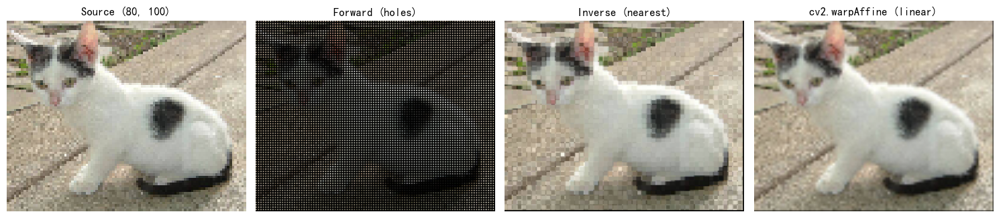

观察：
  ① Forward（手写正向映射）：出现规则的棋盘格空洞
  ② Inverse（手写反向映射，最近邻插值）：无空洞，但略粗糙
  ③ cv2.warpAffine（OpenCV 官方，双线性插值）：无空洞，比 ② 更平滑
结论：OpenCV 的 warpAffine 使用反向映射 + 双线性插值
      ② 和 ③ 都无空洞，验证了 OpenCV 用的是反向映射；
      ③ 比 ② 更平滑，验证了它默认使用双线性插值（详见 2.2.4 与 2.5 节）


In [49]:
# ============ 2.2 实例：正向映射 vs 反向映射可视化 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img = cv2.imread('P&V/cat.jpg')                                                     # 读取 BGR 图像
assert img is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                     # 断言图像读取成功


def forward_mapping_demo(src, M, dst_size):                                         # 定义正向映射函数
    """正向映射演示（可能有空洞）"""                                               # 函数说明
    h, w = src.shape[:2]                                                            # 源图尺寸
    dst_h, dst_w = dst_size                                                         # 目标图尺寸
    dst = np.zeros((dst_h, dst_w, 3), dtype=np.uint8)                               # 目标图（初始全黑）

    for y in range(h):                                                              # 遍历源图每一行
        for x in range(w):                                                          # 遍历源图每一列
            pt = M @ np.array([x, y, 1])                                            # 变换
            nx, ny = int(round(pt[0])), int(round(pt[1]))                           # 取整
            if 0 <= nx < dst_w and 0 <= ny < dst_h:                                 # 边界检查
                dst[ny, nx] = src[y, x]                                             # 写入
    return dst                                                                      # 返回目标图


def inverse_mapping_demo(src, M_inv, dst_size):                                     # 定义反向映射函数
    """反向映射演示（无空洞，用最近邻采样）"""                                     # 函数说明
    h, w = src.shape[:2]                                                            # 源图尺寸
    dst_h, dst_w = dst_size                                                         # 目标图尺寸
    dst = np.zeros((dst_h, dst_w, 3), dtype=np.uint8)                               # 目标图

    for ny in range(dst_h):                                                         # 遍历目标图每一行
        for nx in range(dst_w):                                                     # 遍历目标图每一列
            pt = M_inv @ np.array([nx, ny, 1])                                      # 逆变换
            sx, sy = int(round(pt[0])), int(round(pt[1]))                           # 取整（最近邻）
            if 0 <= sx < w and 0 <= sy < h:                                         # 边界检查
                dst[ny, nx] = src[sy, sx]                                           # 采样
    return dst                                                                      # 返回目标图


# 本次演示需要一张小图：从 img 现场缩小
small_img = cv2.resize(img, (100, 80))                                              # 100x80 小图

# 放大 2.0 倍（整数倍！）
scale = 2.0                                                                         # 缩放因子
M = np.array([[scale, 0, 0],                                                        # 正向矩阵第一行
              [0, scale, 0]], dtype=np.float32)                                     # 正向矩阵第二行
M_inv = np.array([[1/scale, 0, 0],                                                  # 逆向矩阵第一行
                  [0, 1/scale, 0]], dtype=np.float32)                               # 逆向矩阵第二行

dst_size = (int(80 * scale), int(100 * scale))                                      # 目标尺寸 (h, w) = (160, 200)

# 执行三组对照
dst_forward = forward_mapping_demo(small_img, M, dst_size)                          # ① 手写正向（最近邻写入）
dst_inverse = inverse_mapping_demo(small_img, M_inv, dst_size)                      # ② 手写反向（最近邻采样）
dst_cv = cv2.warpAffine(small_img, M, (dst_size[1], dst_size[0]))                   # ③ OpenCV 官方（双线性插值）

# 统计正向映射的空洞率（用一个数字直观说明浪费有多严重）
filled = np.count_nonzero(dst_forward)                                              # 被写入的像素数
total = dst_forward.shape[0] * dst_forward.shape[1] * 3                             # 目标像素总数
print(f'正向映射：目标像素总数 {total}，实际写入 {filled}，空洞率 {(1 - filled/total)*100:.1f}%')  # 打印空洞率

# 显示对比
plt.figure(figsize=(15, 4))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 源图
plt.imshow(cv2.cvtColor(small_img, cv2.COLOR_BGR2RGB))                              # 显示
plt.title(f'Source {small_img.shape[:2]}')                                          # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # ① 手写正向
plt.imshow(cv2.cvtColor(dst_forward, cv2.COLOR_BGR2RGB))                            # 显示
plt.title('Forward (holes)')                                                        # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # ② 手写反向
plt.imshow(cv2.cvtColor(dst_inverse, cv2.COLOR_BGR2RGB))                            # 显示
plt.title('Inverse (nearest)')                                                      # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # ③ OpenCV 官方（对照组）
plt.imshow(cv2.cvtColor(dst_cv, cv2.COLOR_BGR2RGB))                                 # 显示
plt.title('cv2.warpAffine (linear)')                                                # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('观察：')                                                                    # 打印观察
print('  ① Forward（手写正向映射）：出现规则的棋盘格空洞')                          # 观察第一行
print('  ② Inverse（手写反向映射，最近邻插值）：无空洞，但略粗糙')                  # 观察第二行
print('  ③ cv2.warpAffine（OpenCV 官方，双线性插值）：无空洞，比 ② 更平滑')        # 观察第三行
print('结论：OpenCV 的 warpAffine 使用反向映射 + 双线性插值')                       # 结论第一行
print('      ② 和 ③ 都无空洞，验证了 OpenCV 用的是反向映射；')                      # 结论第二行
print('      ③ 比 ② 更平滑，验证了它默认使用双线性插值（详见 2.2.4 与 2.5 节）')    # 结论第三行

> **术语说明**：本节的「放大 2 倍」指的是**像素矩阵的宽高各 ×2**——源图 100×80 变成目标图 200×160，**像素总数变成 4 倍**。
>
> 这不等于「图像在屏幕上显示得更大」——Matplotlib 的 `imshow` 会把每张图拉伸到子图大小，所以四张图**显示尺寸相同**，区别在于**内部像素密度**。这一点在处理图像时非常重要：像素尺寸和显示尺寸是两个独立的概念。

---
# 2.3 缩放、平移、旋转

有了 2.1 的矩阵工具和 2.2 的反向映射策略，现在可以动手实现最常见的三种几何变换了。

## 2.3.1 缩放 cv2.resize

缩放是最简单的：目标坐标 = 源坐标 × 缩放因子。

```python
dst = cv2.resize(src, dsize, fx, fy, interpolation)
```

- `dsize`：目标尺寸 `(width, height)`，若为 `(0, 0)` 则用 `fx, fy`；
- `fx, fy`：缩放因子；
- `interpolation`：插值方法（2.5 节专门讨论，这里先用默认）。

**注意**：`cv2.resize` 是独立函数，不走 `warpAffine`。这是因为缩放可以完全由 `fx, fy` 两个数描述，不需要完整的矩阵。

resize 到 (200, 160): (160, 200, 3)
fx=0.5, fy=0.5: (207, 250, 3)
fx=2.0, fy=2.0 (CUBIC): (828, 1000, 3)


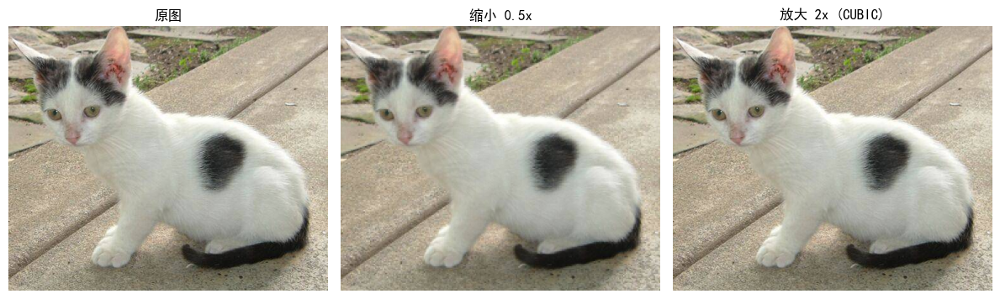

In [50]:
# ============ 2.3.1 实例：缩放 cv2.resize ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查

# 方式一：指定目标尺寸
resized = cv2.resize(img, (200, 160))                               # 目标宽 200、高 160
print('resize 到 (200, 160):', resized.shape)                        # 打印形状

# 方式二：指定缩放因子
resized_half = cv2.resize(img, (0, 0), fx=0.5, fy=0.5)              # 缩小一半
print('fx=0.5, fy=0.5:', resized_half.shape)                         # 打印形状

# 方式三：放大两倍 + 双三次插值
resized_double = cv2.resize(img, (0, 0), fx=2.0, fy=2.0,
                            interpolation=cv2.INTER_CUBIC)          # 双三次插值
print('fx=2.0, fy=2.0 (CUBIC):', resized_double.shape)               # 打印形状

plt.figure(figsize=(12, 4))                                         # 画布
for i, (title, im) in enumerate([('原图', img), ('缩小 0.5x', resized_half), ('放大 2x (CUBIC)', resized_double)]):  # 遍历
    plt.subplot(1, 3, i + 1)                                        # 子图
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))                 # 显示
    plt.title(title)                                                # 标题
    plt.axis('off')                                                 # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

## 2.3.2 平移 warpAffine

平移就是把每个点都加上 `(tx, ty)`。用 2×3 矩阵表示：

$$
M = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \end{bmatrix}
$$

OpenCV 中通过 `cv2.warpAffine` 实现。

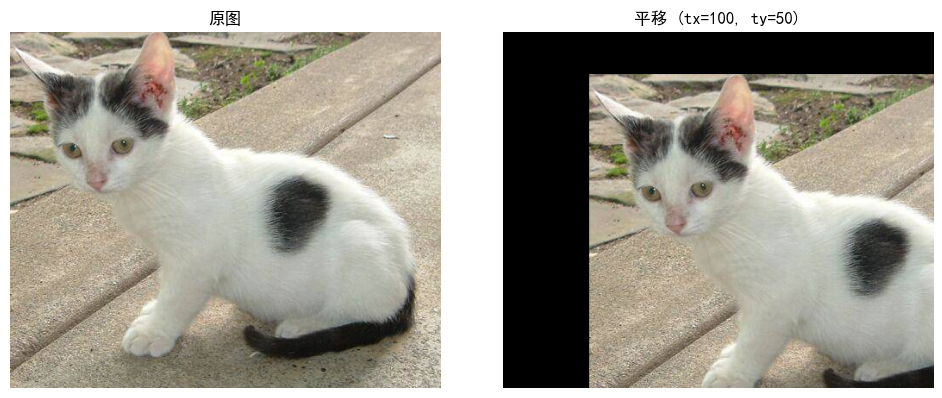

In [51]:
# ============ 2.3.2 实例：平移 warpAffine ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查
h, w = img.shape[:2]                                                # 高宽

# 平移矩阵：向右 100 像素，向下 50 像素
tx, ty = 100, 50                                                    # 平移量
M = np.float32([[1, 0, tx],                                         # 第一行
                [0, 1, ty]])                                        # 第二行

shifted = cv2.warpAffine(img, M, (w, h))                            # 输出尺寸与原图相同

plt.figure(figsize=(10, 4))                                         # 画布
plt.subplot(1, 2, 1)                                                # 原图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))                    # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 2, 2)                                                # 平移后
plt.imshow(cv2.cvtColor(shifted, cv2.COLOR_BGR2RGB))                # 显示
plt.title(f'平移 (tx={tx}, ty={ty})')                                # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

## 2.3.3 旋转 getRotationMatrix2D

旋转矩阵需要指定旋转中心、旋转角度（逆时针为正）和缩放因子。OpenCV 提供了 `cv2.getRotationMatrix2D` 直接生成 2×3 矩阵。

```python
M = cv2.getRotationMatrix2D(center, angle, scale)
```

- `center`：旋转中心 `(cx, cy)`；
- `angle`：旋转角度（度，逆时针为正）；
- `scale`：缩放因子。

旋转矩阵：
 [[  0.70710678   0.70710678 -73.147799  ]
 [ -0.70710678   0.70710678 237.40559159]]


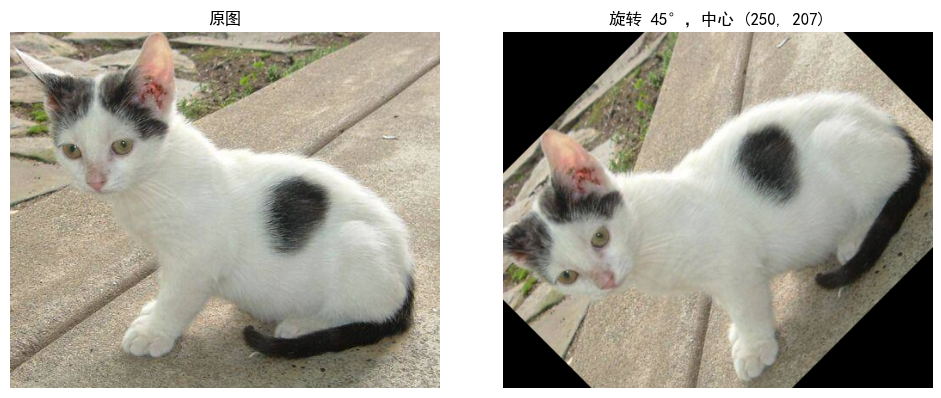

In [52]:
# ============ 2.3.3 实例：旋转 getRotationMatrix2D ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查
h, w = img.shape[:2]                                                # 高宽

# 以图像中心旋转 45 度，不缩放
center = (w // 2, h // 2)                                           # 旋转中心
angle = 45                                                          # 旋转角度
scale = 1.0                                                         # 缩放因子
M = cv2.getRotationMatrix2D(center, angle, scale)                   # 生成旋转矩阵
print('旋转矩阵：\n', M)                                            # 打印矩阵

rotated = cv2.warpAffine(img, M, (w, h))                            # 执行旋转

plt.figure(figsize=(10, 4))                                         # 画布
plt.subplot(1, 2, 1)                                                # 原图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))                    # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 2, 2)                                                # 旋转后
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))                # 显示
plt.title(f'旋转 {angle}°，中心 {center}')                           # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.4 仿射变换与透视变换

2.3 的三种变换都可以统一用 `cv2.warpAffine` 完成。但实际应用中，我们往往只知道**源图上几个点**和**目标图上对应的几个点**，希望自动求出变换矩阵。

- **仿射变换**：需要 **3 对**对应点，用 `cv2.getAffineTransform` 求 2×3 矩阵；
- **透视变换**：需要 **4 对**对应点，用 `cv2.getPerspectiveTransform` 求 3×3 矩阵。

## 2.4.1 仿射变换 getAffineTransform

仿射变换保持平行性，需要 3 个点来确定。常用于图像配准、简单倾斜校正等。

```python
M = cv2.getAffineTransform(src_pts, dst_pts)
```

- `src_pts`：源图上 3 个点，形状 `(3, 2)`；
- `dst_pts`：目标图上对应的 3 个点，形状 `(3, 2)`。

仿射矩阵：
 [[0.80160321 0.12106538 0.        ]
 [0.08296593 0.80193708 0.        ]]


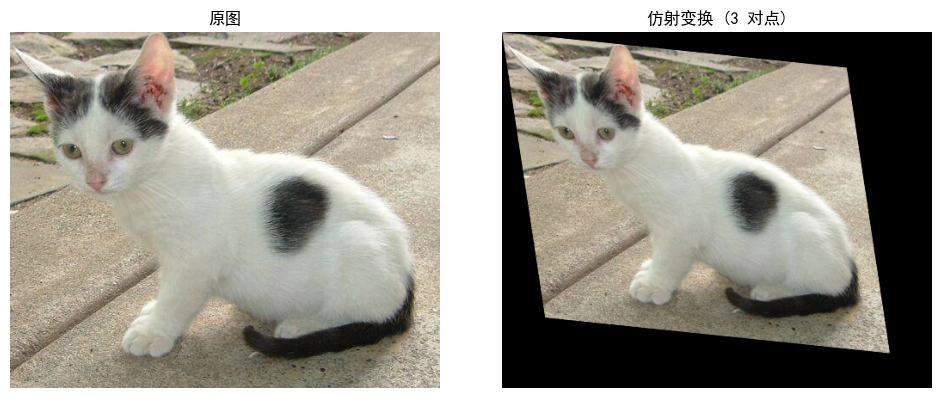

In [53]:
# ============ 2.4.1 实例：仿射变换 getAffineTransform ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查
h, w = img.shape[:2]                                                # 高宽

# 源图三个点（左上、右上、左下）
src_pts = np.float32([[0, 0], [w - 1, 0], [0, h - 1]])              # 源点
# 目标图三个点：将右上角向右拉伸，左下角向下拉伸
dst_pts = np.float32([[0, 0], [w * 0.8, h * 0.1], [w * 0.1, h * 0.8]])  # 目标点

M = cv2.getAffineTransform(src_pts, dst_pts)                        # 求仿射矩阵
print('仿射矩阵：\n', M)                                            # 打印矩阵

affined = cv2.warpAffine(img, M, (w, h))                            # 执行仿射变换

plt.figure(figsize=(10, 4))                                         # 画布
plt.subplot(1, 2, 1)                                                # 原图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))                    # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 2, 2)                                                # 仿射后
plt.imshow(cv2.cvtColor(affined, cv2.COLOR_BGR2RGB))                # 显示
plt.title('仿射变换 (3 对点)')                                       # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

## 2.4.2 透视变换 getPerspectiveTransform

透视变换不保持平行性，需要 4 个点来确定。常用于文档矫正、鸟瞰图生成等。

```python
H = cv2.getPerspectiveTransform(src_pts, dst_pts)
```

- `src_pts`：源图上 4 个点，形状 `(4, 2)`；
- `dst_pts`：目标图上对应的 4 个点，形状 `(4, 2)`。

透视矩阵：
 [[ 6.01202405e-01 -2.42130751e-01  1.00000000e+02]
 [ 0.00000000e+00  6.01202405e-01  0.00000000e+00]
 [ 0.00000000e+00 -9.65611611e-04  1.00000000e+00]]


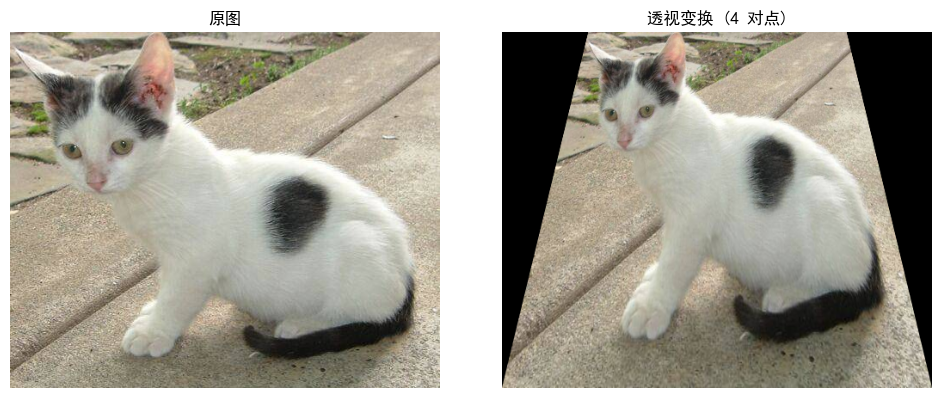

In [54]:
# ============ 2.4.2 实例：透视变换 getPerspectiveTransform ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查
h, w = img.shape[:2]                                                # 高宽

# 源图四个点（左上、右上、右下、左下）
src_pts = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]])  # 源点
# 目标图四个点：模拟从侧面看的效果（上边窄、下边宽）
dst_pts = np.float32([[w * 0.2, 0], [w * 0.8, 0],
                      [w - 1, h - 1], [0, h - 1]])                   # 目标点

H = cv2.getPerspectiveTransform(src_pts, dst_pts)                   # 求透视矩阵
print('透视矩阵：\n', H)                                            # 打印矩阵

warped = cv2.warpPerspective(img, H, (w, h))                        # 执行透视变换

plt.figure(figsize=(10, 4))                                         # 画布
plt.subplot(1, 2, 1)                                                # 原图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))                    # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 2, 2)                                                # 透视后
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))                 # 显示
plt.title('透视变换 (4 对点)')                                       # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.5 插值方法详解

在 2.2.4 节我们提到，反向映射算出的源坐标是小数，必须用插值。本节详细讨论 OpenCV 支持的五种插值方法。

| 方法 | 常量 | 原理 | 速度 | 质量 | 适用场景 |
|------|------|------|------|------|----------|
| 最近邻 | `INTER_NEAREST` | 取最近的整数像素 | 最快 | 最差 | 实时性要求极高、掩码图 |
| 双线性 | `INTER_LINEAR` | 周围 4 像素加权平均 | 快 | 中等 | 默认选择，通用 |
| 双三次 | `INTER_CUBIC` | 周围 16 像素加权平均 | 慢 | 好 | 放大图像 |
| Lanczos | `INTER_LANCZOS4` | 周围 64 像素加权平均 | 最慢 | 最好 | 高质量放大 |
| 面积 | `INTER_AREA` | 按面积加权平均 | 中等 | 好 | 缩小图像（抗混叠） |

**选择建议**：
- **放大**：用 `INTER_CUBIC` 或 `INTER_LANCZOS4`；
- **缩小**：用 `INTER_AREA`（抗混叠效果最好）；
- **通用**：`INTER_LINEAR` 是默认选择，速度和质量的平衡点。

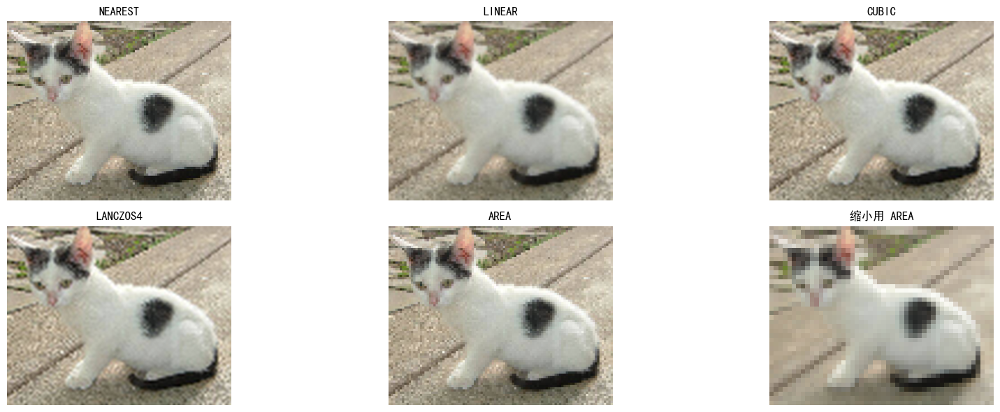

观察：
  NEAREST：有明显锯齿/马赛克
  LINEAR：比 NEAREST 平滑
  CUBIC/LANCZOS4：更平滑，细节更好
  缩小用 AREA：比 LINEAR 更少混叠


In [55]:
# ============ 2.5 实例：插值方法对比 ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查

# 为了看清插值效果，先缩小再放大
small = cv2.resize(img, (100, 80))                                  # 缩小到 100x80

# 用五种插值方法放大 4 倍
methods = [                                                         # 插值方法列表
    ('NEAREST', cv2.INTER_NEAREST),                                 # 最近邻
    ('LINEAR', cv2.INTER_LINEAR),                                   # 双线性
    ('CUBIC', cv2.INTER_CUBIC),                                     # 双三次
    ('LANCZOS4', cv2.INTER_LANCZOS4),                               # Lanczos
    ('AREA', cv2.INTER_AREA),                                       # 面积
]

plt.figure(figsize=(18, 6))                                         # 画布
for i, (name, flag) in enumerate(methods):                          # 遍历
    resized = cv2.resize(small, (0, 0), fx=4, fy=4, interpolation=flag)  # 放大 4 倍
    plt.subplot(2, 3, i + 1)                                        # 子图
    plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))            # 显示
    plt.title(f'{name}')                                            # 标题
    plt.axis('off')                                                 # 关闭坐标轴

# 最后一张：缩小用 AREA
shrunk = cv2.resize(img, (50, 40), interpolation=cv2.INTER_AREA)    # 缩小
plt.subplot(2, 3, 6)                                                # 子图
plt.imshow(cv2.cvtColor(shrunk, cv2.COLOR_BGR2RGB))                 # 显示
plt.title('缩小用 AREA')                                            # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

print('观察：')                                                     # 打印观察
print('  NEAREST：有明显锯齿/马赛克')                                # 观察第一行
print('  LINEAR：比 NEAREST 平滑')                                   # 观察第二行
print('  CUBIC/LANCZOS4：更平滑，细节更好')                          # 观察第三行
print('  缩小用 AREA：比 LINEAR 更少混叠')                           # 观察第四行

---
# 2.6 翻转、裁剪、拼接

这三种操作不改变像素值，只改变像素位置，是最基础的空间操作。

- **翻转**：`cv2.flip`，左右/上下/同时翻转；
- **裁剪**：NumPy 切片 `img[y1:y2, x1:x2]`；
- **拼接**：`np.hstack` / `np.vstack` 或 `cv2.hconcat` / `cv2.vconcat`。

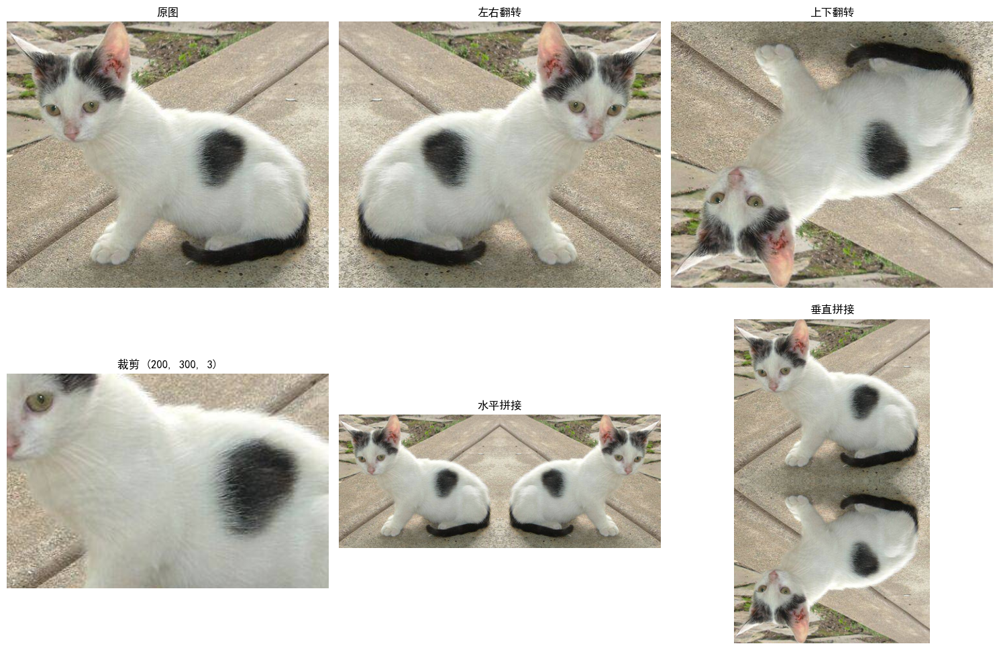

In [56]:
# ============ 2.6 实例：翻转、裁剪、拼接 ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查
h, w = img.shape[:2]                                                # 高宽

# 翻转
flip_lr = cv2.flip(img, 1)                                          # 左右翻转
flip_ud = cv2.flip(img, 0)                                          # 上下翻转
flip_both = cv2.flip(img, -1)                                       # 同时翻转

# 裁剪：取中心区域
cy, cx = h // 2, w // 2                                             # 中心
crop = img[cy - 100:cy + 100, cx - 150:cx + 150]                    # 裁剪 300x200

# 拼接：水平拼接原图和翻转图
hstack = np.hstack([img, flip_lr])                                  # 水平拼接
vstack = np.vstack([img, flip_ud])                                  # 垂直拼接

plt.figure(figsize=(15, 10))                                        # 画布
plt.subplot(2, 3, 1)                                                # 原图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))                    # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 3, 2)                                                # 左右翻转
plt.imshow(cv2.cvtColor(flip_lr, cv2.COLOR_BGR2RGB))                # 显示
plt.title('左右翻转')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 3, 3)                                                # 上下翻转
plt.imshow(cv2.cvtColor(flip_ud, cv2.COLOR_BGR2RGB))                # 显示
plt.title('上下翻转')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 3, 4)                                                # 裁剪
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))                   # 显示
plt.title(f'裁剪 {crop.shape}')                                     # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 3, 5)                                                # 水平拼接
plt.imshow(cv2.cvtColor(hstack, cv2.COLOR_BGR2RGB))                 # 显示
plt.title('水平拼接')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 3, 6)                                                # 垂直拼接
plt.imshow(cv2.cvtColor(vstack, cv2.COLOR_BGR2RGB))                 # 显示
plt.title('垂直拼接')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.7 图像金字塔

图像金字塔是一系列**分辨率逐渐降低**的图像集合。最常用的是**高斯金字塔**和**拉普拉斯金字塔**。

- **高斯金字塔**：先高斯模糊，再下采样（隔行隔列取像素）；
- **拉普拉斯金字塔**：由高斯金字塔相邻层相减得到，保留细节。

OpenCV 提供了：
- `cv2.pyrDown`：下采样（尺寸减半）；
- `cv2.pyrUp`：上采样（尺寸加倍）。

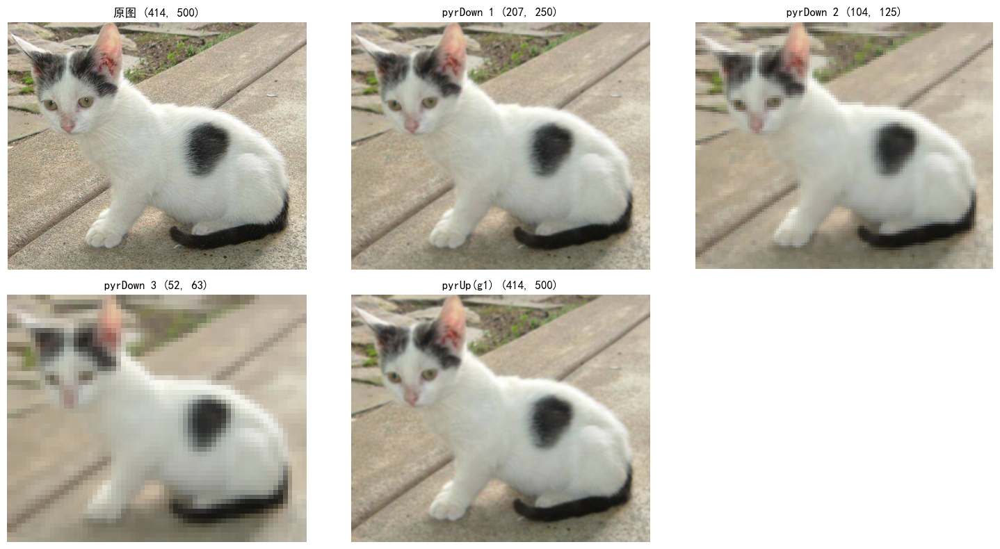

In [57]:
# ============ 2.7 实例：图像金字塔 ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查

# 高斯金字塔：连续下采样
g1 = cv2.pyrDown(img)                                               # 第 1 层
g2 = cv2.pyrDown(g1)                                                # 第 2 层
g3 = cv2.pyrDown(g2)                                                # 第 3 层

# 上采样
up1 = cv2.pyrUp(g1)                                                 # 从 g1 上采样

plt.figure(figsize=(15, 8))                                         # 画布
for i, (title, im) in enumerate([('原图', img), ('pyrDown 1', g1),
                                  ('pyrDown 2', g2), ('pyrDown 3', g3),
                                  ('pyrUp(g1)', up1)]):             # 遍历
    plt.subplot(2, 3, i + 1)                                        # 子图
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))                 # 显示
    plt.title(f'{title} {im.shape[:2]}')                            # 标题
    plt.axis('off')                                                 # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.8 重映射 remap

`cv2.remap` 是最通用的空间变换函数——你可以为**每个目标像素**指定一个源坐标。

```python
dst = cv2.remap(src, map_x, map_y, interpolation)
```

- `map_x`：目标图每个像素对应的**源图 x 坐标**，形状与目标图相同；
- `map_y`：目标图每个像素对应的**源图 y 坐标**，形状与目标图相同；
- `interpolation`：插值方法。

`remap` 是**反向映射**的直接实现——你给的是「目标像素从哪里来」，而不是「源像素去哪里」。

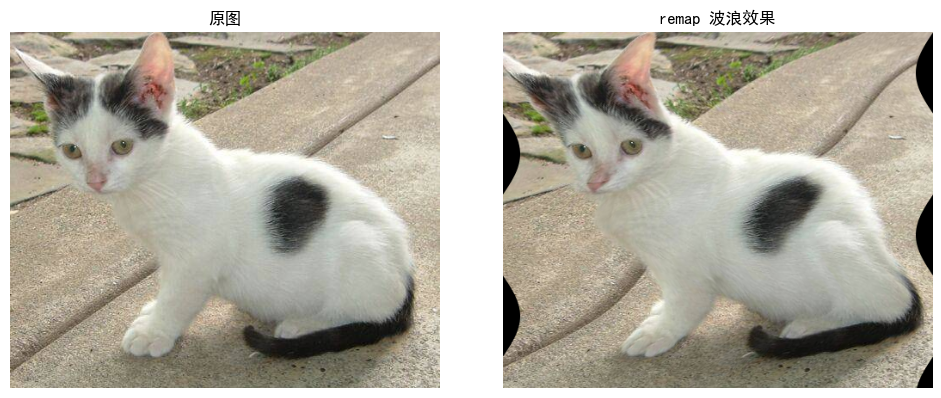

In [58]:
# ============ 2.8 实例：重映射 remap ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查
h, w = img.shape[:2]                                                # 高宽

# 构造 map_x 和 map_y
map_x, map_y = np.meshgrid(np.arange(w), np.arange(h))              # 默认映射：恒等
map_x = map_x.astype(np.float32)                                    # 转为 float32
map_y = map_y.astype(np.float32)                                    # 转为 float32

# 波浪效果：x 坐标加正弦扰动
map_x_wave = map_x + 20 * np.sin(map_y / 30.0)                      # x 方向扰动
map_x_wave = map_x_wave.astype(np.float32)                          # 转为 float32

remapped = cv2.remap(img, map_x_wave, map_y, cv2.INTER_LINEAR)      # 重映射

plt.figure(figsize=(10, 4))                                         # 画布
plt.subplot(1, 2, 1)                                                # 原图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))                    # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 2, 2)                                                # 重映射后
plt.imshow(cv2.cvtColor(remapped, cv2.COLOR_BGR2RGB))               # 显示
plt.title('remap 波浪效果')                                         # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.9 极坐标变换 warpPolar

极坐标变换把图像从**笛卡尔坐标系**转换到**极坐标系**（或反过来）。常用于：
- 圆形区域展开（如展开表盘、展开鱼眼图像）；
- 旋转不变性分析。

```python
dst = cv2.warpPolar(src, dsize, center, maxRadius, flags)
```

- `dsize`：输出尺寸；
- `center`：极坐标原点；
- `maxRadius`：最大半径；
- `flags`：`WARP_POLAR_LINEAR`（线性极坐标）或 `WARP_POLAR_LOG`（对数极坐标），可组合 `WARP_INVERSE_MAP`。

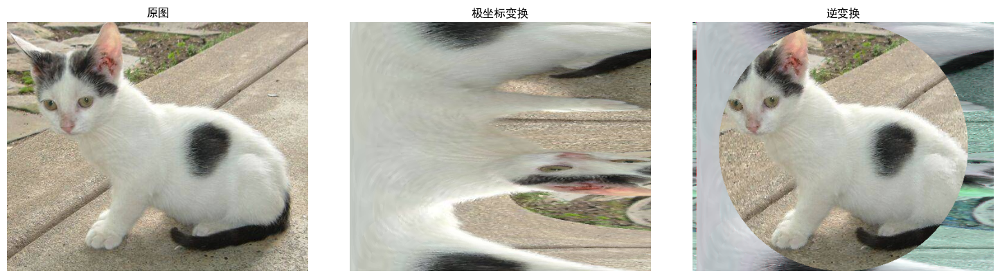

In [59]:
# ============ 2.9 实例：极坐标变换 warpPolar ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查
h, w = img.shape[:2]                                                # 高宽

# 极坐标变换
center = (w // 2, h // 2)                                           # 中心
max_radius = min(w, h) // 2                                         # 最大半径
polar = cv2.warpPolar(img, (w, h), center, max_radius,
                       cv2.WARP_POLAR_LINEAR)                       # 线性极坐标

# 逆变换
inverse = cv2.warpPolar(polar, (w, h), center, max_radius,
                         cv2.WARP_POLAR_LINEAR + cv2.WARP_INVERSE_MAP)  # 逆变换

plt.figure(figsize=(15, 4))                                         # 画布
plt.subplot(1, 3, 1)                                                # 原图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))                    # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 3, 2)                                                # 极坐标
plt.imshow(cv2.cvtColor(polar, cv2.COLOR_BGR2RGB))                  # 显示
plt.title('极坐标变换')                                             # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 3, 3)                                                # 逆变换
plt.imshow(cv2.cvtColor(inverse, cv2.COLOR_BGR2RGB))                # 显示
plt.title('逆变换')                                                 # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.10 图像阈值化

阈值化是最简单的像素域操作：把像素值分为两类（或更多类）。

```python
ret, dst = cv2.threshold(src, thresh, maxval, type)
```

常用类型：
- `THRESH_BINARY`：大于阈值 → maxval，否则 → 0；
- `THRESH_BINARY_INV`：反过来；
- `THRESH_TRUNC`：大于阈值 → 阈值，否则不变；
- `THRESH_TOZERO`：大于阈值不变，否则 → 0；
- `THRESH_OTSU`：自动确定阈值（仅灰度图）；
- `THRESH_TRIANGLE`：三角形法自动确定阈值。

> **本节说明**：本节的目的是**对比各种阈值类型**，因此故意展示硬编码 `127` 与 Otsu 的差别。
> 实际工程中，应按「看位深 → 扫分布 → 定阈值」的流程处理（**见附录 B**）。
> 关于 Otsu 这个名字的由来，**见附录 A**。

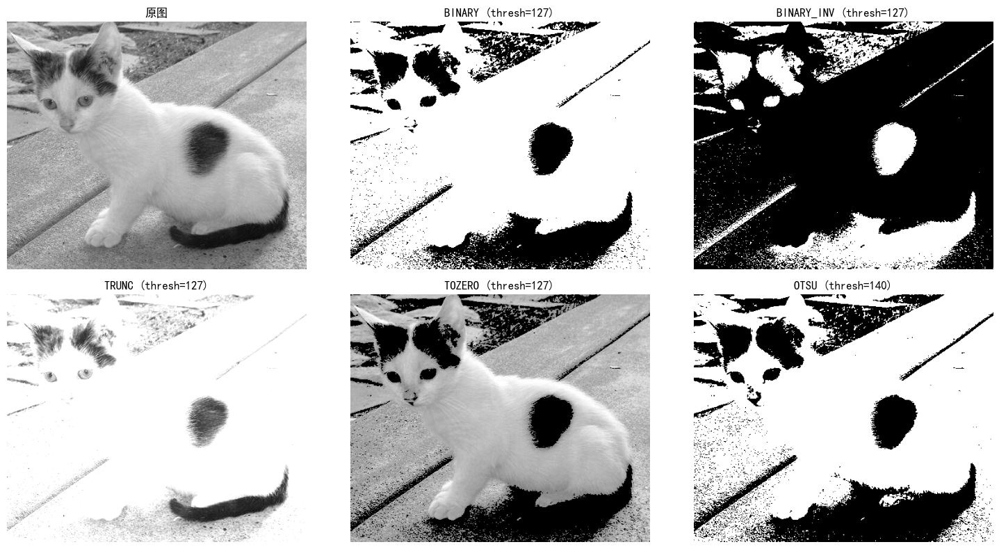

In [60]:
# ============ 2.10 实例：图像阈值化 ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg', cv2.IMREAD_GRAYSCALE)               # 读取灰度图
assert img is not None, '图像读取失败'                               # 检查

# 固定阈值
ret1, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)         # 二值化
ret2, th2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)     # 反二值化
ret3, th3 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)          # 截断
ret4, th4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)         # 小于阈值置零

# 自动阈值
ret5, th5 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # Otsu

plt.figure(figsize=(15, 8))                                         # 画布
for i, (title, im, t) in enumerate([('原图', img, None),
                                     ('BINARY', th1, ret1),
                                     ('BINARY_INV', th2, ret2),
                                     ('TRUNC', th3, ret3),
                                     ('TOZERO', th4, ret4),
                                     ('OTSU', th5, ret5)]):         # 遍历
    plt.subplot(2, 3, i + 1)                                        # 子图
    plt.imshow(im, cmap='gray')                                     # 显示
    plt.title(f'{title}' + (f' (thresh={t:.0f})' if t else ''))     # 标题
    plt.axis('off')                                                 # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.11 图像平滑（滤波）

平滑（模糊）是像素域处理中最常用的操作之一，用于去噪、降低细节。

OpenCV 提供了：
- `cv2.blur`：均值滤波；
- `cv2.GaussianBlur`：高斯滤波；
- `cv2.medianBlur`：中值滤波；
- `cv2.bilateralFilter`：双边滤波（保边去噪）。

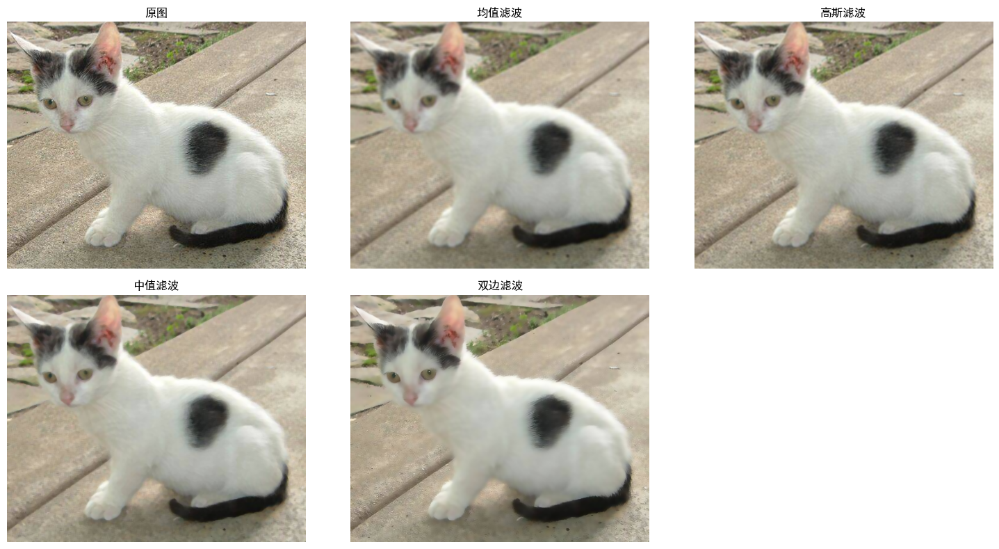

In [61]:
# ============ 2.11 实例：图像平滑（滤波） ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查

# 均值滤波
blur = cv2.blur(img, (5, 5))                                        # 5x5 均值

# 高斯滤波
gaussian = cv2.GaussianBlur(img, (5, 5), 0)                         # 5x5 高斯

# 中值滤波
median = cv2.medianBlur(img, 5)                                     # 5x5 中值

# 双边滤波
bilateral = cv2.bilateralFilter(img, 9, 75, 75)                     # 双边

plt.figure(figsize=(15, 8))                                         # 画布
for i, (title, im) in enumerate([('原图', img), ('均值滤波', blur),
                                  ('高斯滤波', gaussian), ('中值滤波', median),
                                  ('双边滤波', bilateral)]):        # 遍历
    plt.subplot(2, 3, i + 1)                                        # 子图
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))                 # 显示
    plt.title(title)                                                # 标题
    plt.axis('off')                                                 # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.12 滤波边界处理

滤波时，图像边缘的像素没有完整的邻域，需要**边界填充**。OpenCV 支持：

| 常量 | 说明 |
|------|------|
| `BORDER_CONSTANT` | 用常数填充（默认 0） |
| `BORDER_REPLICATE` | 复制边缘像素 |
| `BORDER_REFLECT` | 镜像反射（含边缘） |
| `BORDER_REFLECT_101` | 镜像反射（不含边缘，默认） |
| `BORDER_WRAP` | 环绕 |

可以用 `cv2.copyMakeBorder` 手动测试不同边界效果。

测试图像：
 [[  0  10  20  30  40]
 [ 50  60  70  80  90]
 [100 110 120 130 140]
 [150 160 170 180 190]
 [200 210 220 230 240]]


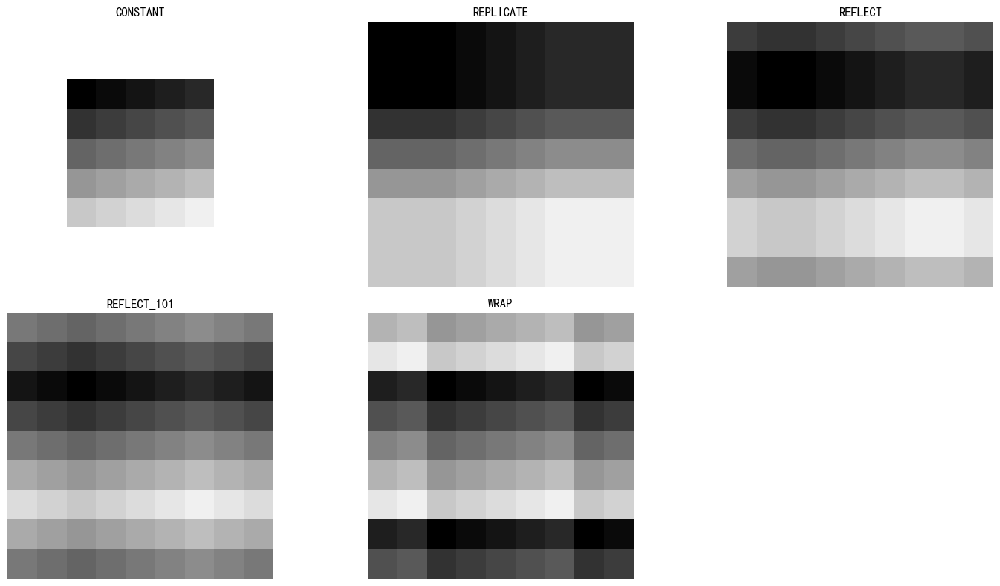

In [62]:
# ============ 2.12 实例：滤波边界处理 ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

# 创建一个 5x5 的测试图像
test = np.arange(25, dtype=np.uint8).reshape(5, 5) * 10             # 0, 10, ..., 240
print('测试图像：\n', test)                                        # 打印

# 四种边界填充
border_types = [                                                    # 边界类型列表
    ('CONSTANT', cv2.BORDER_CONSTANT),                              # 常数
    ('REPLICATE', cv2.BORDER_REPLICATE),                            # 复制
    ('REFLECT', cv2.BORDER_REFLECT),                                # 反射（含边缘）
    ('REFLECT_101', cv2.BORDER_REFLECT_101),                        # 反射（不含边缘）
    ('WRAP', cv2.BORDER_WRAP),                                      # 环绕
]

plt.figure(figsize=(15, 8))                                         # 画布
for i, (name, border) in enumerate(border_types):                   # 遍历
    padded = cv2.copyMakeBorder(test, 2, 2, 2, 2, border, value=255)  # 填充 2 像素
    plt.subplot(2, 3, i + 1)                                        # 子图
    plt.imshow(padded, cmap='gray', vmin=0, vmax=255)               # 显示
    plt.title(name)                                                 # 标题
    plt.axis('off')                                                 # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.13 图像锐化与 USM

锐化用于增强图像细节。常用的方法：

1. **直接锐化**：用拉普拉斯核或自定义锐化核做 `filter2D`；
2. **USM（Unsharp Mask）**：原图 - 模糊图 = 细节，再把细节加回原图。

USM 步骤：
1. 对原图做高斯模糊，得到 `blurred`；
2. 计算 `detail = original - blurred`；
3. 输出 `sharpened = original + amount * detail`。

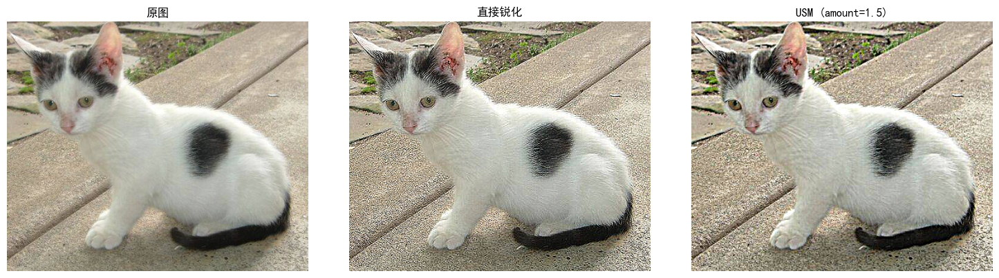

In [63]:
# ============ 2.13 实例：图像锐化与 USM ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg')                                     # 读取图像
assert img is not None, '图像读取失败'                               # 检查

# 方法一：直接锐化（拉普拉斯核）
kernel_sharpen = np.array([[0, -1, 0],                              # 锐化核第一行
                            [-1, 5, -1],                            # 锐化核第二行
                            [0, -1, 0]])                            # 锐化核第三行
sharpened = cv2.filter2D(img, -1, kernel_sharpen)                   # 直接锐化

# 方法二：USM
blurred = cv2.GaussianBlur(img, (0, 0), 3)                          # 高斯模糊
detail = cv2.subtract(img.astype(np.float32), blurred.astype(np.float32))  # 细节
amount = 1.5                                                        # 锐化强度
usm = cv2.add(img.astype(np.float32), amount * detail)              # 加回细节
usm = np.clip(usm, 0, 255).astype(np.uint8)                         # 截断

plt.figure(figsize=(15, 4))                                         # 画布
plt.subplot(1, 3, 1)                                                # 原图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))                    # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 3, 2)                                                # 直接锐化
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))              # 显示
plt.title('直接锐化')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 3, 3)                                                # USM
plt.imshow(cv2.cvtColor(usm, cv2.COLOR_BGR2RGB))                    # 显示
plt.title(f'USM (amount={amount})')                                 # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.14 形态学操作

## 2.14.1 形态学是什么

形态学（Morphology）原本是生物学中研究动植物形态的学科。在图像处理中，**形态学操作**指的是用一个小窗口（叫**结构元素**，structuring element）在图像上滑动，根据窗口内像素的分布对中心像素做判断。

形态学最常用于**二值图像**（只有两种值，通常取 0 和 255；关于这个措辞的严谨性，**见附录 C**），但也适用于灰度图。它的核心思想是：

- **腐蚀**（Erosion）：让白色区域**变小**；
- **膨胀**（Dilation）：让白色区域**变大**。

> 为什么腐蚀/膨胀的描述只提白色，黑色被晾在一边？这不是「白色特殊」，而是约定俗成的前景/背景设定决定的（**详见附录 D**）。
开运算、闭运算、梯度、顶帽、黑帽都是这两种基本操作的组合。

本节用一张**指纹图像**来演示——指纹的脊线又细又密，形态学操作的效果非常直观。

## 2.14.2 腐蚀与膨胀：最基础的两个操作

### 腐蚀 cv2.erode

**规则**：结构元素覆盖的区域内，**只要有一个像素是 0（黑），中心像素就变成 0**。

效果：白色区域**向内收缩**，细小的白色噪点被消除，细线被断开。

```python
eroded = cv2.erode(src, kernel, iterations=1)
```

### 膨胀 cv2.dilate

**规则**：结构元素覆盖的区域内，**只要有一个像素是 255（白），中心像素就变成 255**。

效果：白色区域**向外扩张**，小的黑色孔洞被填满，断裂的线被连接。

```python
dilated = cv2.dilate(src, kernel, iterations=1)
```

### 结构元素 kernel

结构元素决定了操作的形状和范围。最常用的是矩形核：

```python
kernel = np.ones((3, 3), np.uint8)   # 3x3 全 1 矩形核
```

- 核越大，腐蚀/膨胀越强；
- `iterations` 参数可以重复多次操作，效果等同于用更大的核。

### 阈值化的正确流程

本节的二值化按三步走（**详见附录 B**）；其中 Otsu 这个名字的由来，**见附录 A**：

1. **看位深**：用 `IMREAD_UNCHANGED` 原样读取，查看 `dtype` 和实际 `min/max`；
2. **扫分布**：用 `np.unique` 看唯一值个数，判断图像是否已经是二值图；
3. **定阈值**：若已是二值 → 直接用；否则 → 用 Otsu 自动在直方图上找双峰谷底。

dtype（位深）: uint8
实际 min/max: 0 255
唯一值个数: 193
→ Otsu 自动选定阈值 = 113.0


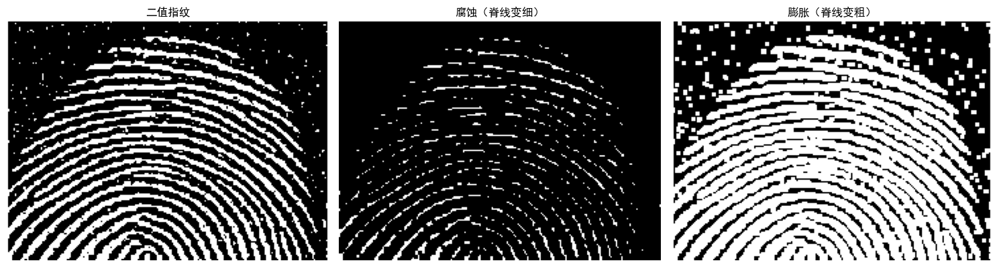

In [64]:
# ============ 2.14.2 实例：腐蚀与膨胀（指纹演示） ============
# 本节完全独立：自己导入库、自己读取图像、自己定阈值

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

# ---------- 第一步：看位深（原样读，不要擅自改） ----------
finger = cv2.imread('P&V/noisy-fingerprint.png', cv2.IMREAD_UNCHANGED)  # 原样读取，保留位深
assert finger is not None, '图像读取失败，请检查路径'                 # 检查
if finger.ndim == 3:                                                # 若是彩色
    finger = cv2.cvtColor(finger, cv2.COLOR_BGR2GRAY)               # 转灰度

print('dtype（位深）:', finger.dtype)                               # uint8 / uint16 ...
print('实际 min/max:', finger.min(), finger.max())                  # 实际值域

# ---------- 第二步：扫分布（看唯一值，判断是不是伪二值） ----------
uniq = np.unique(finger)                                            # 全部唯一值
print('唯一值个数:', len(uniq))                                     # 用来判断是不是伪二值

# ---------- 第三步：定阈值 ----------
if len(uniq) <= 2:                                                  # 本来就是二值图
    print('→ 图像本身就是二值图，无需阈值化，直接使用')               # 说明
    finger_bin = finger.copy()                                      # 直接拿来用
else:                                                               # 需要切一刀
    # Otsu 在直方图上自动找双峰谷底；thresh 填 0 是占位符，被忽略
    ret, finger_bin = cv2.threshold(finger, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # 自动阈值
    print(f'→ Otsu 自动选定阈值 = {ret:.1f}')                        # 查看 Otsu 选了多少

# 定义结构元素
kernel = np.ones((3, 3), np.uint8)                                  # 3x3 矩形核

# 腐蚀：脊线变细
eroded = cv2.erode(finger_bin, kernel, iterations=1)                # 腐蚀一次

# 膨胀：脊线变粗
dilated = cv2.dilate(finger_bin, kernel, iterations=1)              # 膨胀一次

plt.figure(figsize=(15, 4))                                         # 画布
plt.subplot(1, 3, 1)                                                # 原图
plt.imshow(finger_bin, cmap='gray')                                 # 显示
plt.title('二值指纹')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 3, 2)                                                # 腐蚀
plt.imshow(eroded, cmap='gray')                                     # 显示
plt.title('腐蚀（脊线变细）')                                        # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 3, 3)                                                # 膨胀
plt.imshow(dilated, cmap='gray')                                    # 显示
plt.title('膨胀（脊线变粗）')                                        # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

## 2.14.3 开运算与闭运算

### 开运算 cv2.MORPH_OPEN

**先腐蚀，后膨胀**。

效果：
- 去除小的白色噪点（腐蚀时被消除）；
- 保留大的白色区域（膨胀时恢复大致形状）；
- 在细线处会断开。

### 闭运算 cv2.MORPH_CLOSE

**先膨胀，后腐蚀**。

效果：
- 填充白色区域内的小黑孔（膨胀时被填满）；
- 连接断裂的白色线（膨胀时连上）；
- 整体形状基本不变（腐蚀时恢复）。

```python
opened = cv2.morphologyEx(src, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(src, cv2.MORPH_CLOSE, kernel)
```

> 关于「开」「闭」这两个名字的来历、以及如何从字面理解它们，**参见附录 E**。

dtype（位深）: uint8
实际 min/max: 0 255
唯一值个数: 193
→ Otsu 自动选定阈值 = 113.0


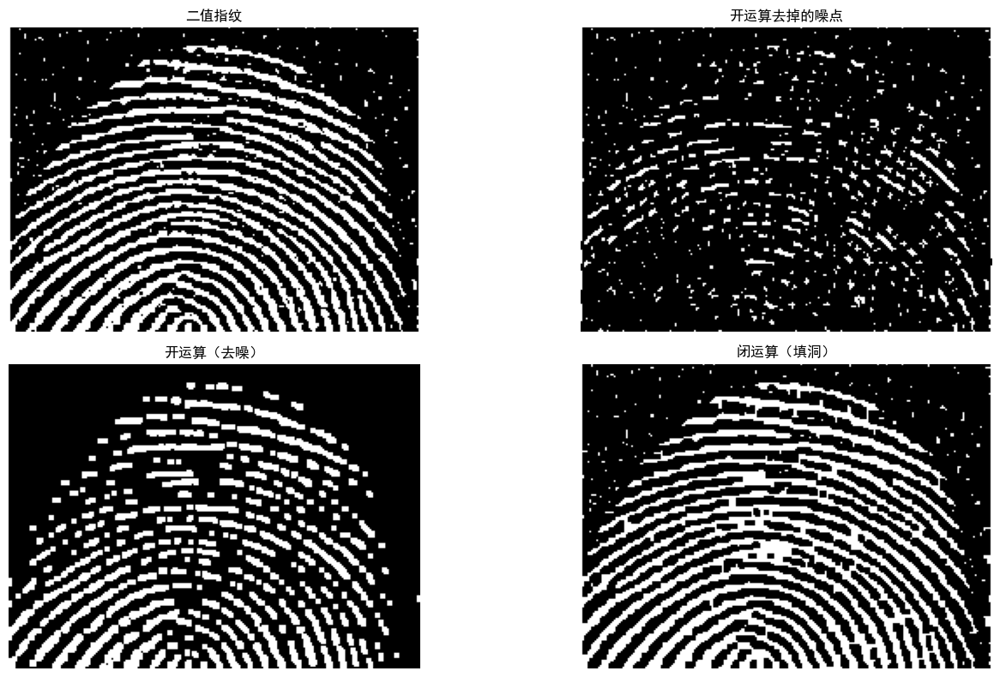

In [65]:
# ============ 2.14.3 实例：开运算与闭运算（指纹演示） ============
# 本节完全独立：自己导入库、自己读取图像、自己二值化、自己定义核

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

# ---------- 第一步：读取图像，原样读，不要擅自改位深 ----------
finger = cv2.imread('P&V/noisy-fingerprint.png', cv2.IMREAD_UNCHANGED)  # 原样读取，保留位深
assert finger is not None, '图像读取失败，请检查路径: P&V/noisy-fingerprint.png'  # 检查
if finger.ndim == 3:                                                # 若是彩色
    finger = cv2.cvtColor(finger, cv2.COLOR_BGR2GRAY)               # 转灰度

# ---------- 第二步：看位深 + 扫分布，决定阈值该落哪 ----------
print('dtype（位深）:', finger.dtype)                               # 位深：uint8 / uint16 ...
print('实际 min/max:', finger.min(), finger.max())                  # 实际值域
uniq = np.unique(finger)                                            # 全部唯一值
print('唯一值个数:', len(uniq))                                     # 用来判断是不是伪二值

if len(uniq) <= 2:                                                  # 情况：本来就是二值图
    print('→ 图像本身就是二值图，无需阈值化，直接使用')               # 说明
    finger_bin = finger.copy()                                      # 直接拿来用
else:                                                               # 情况：需要切一刀
    # Otsu 自动在直方图上找双峰谷底；thresh 填 0 是占位符，被忽略
    ret, finger_bin = cv2.threshold(finger, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # 自动阈值
    print(f'→ Otsu 自动选定阈值 = {ret:.1f}')                        # 查看 Otsu 选了多少

# ---------- 第三步：形态学操作 ----------
kernel = np.ones((3, 3), np.uint8)                                  # 3x3 矩形核
opened = cv2.morphologyEx(finger_bin, cv2.MORPH_OPEN, kernel)       # 开运算（去白噪点）
closed = cv2.morphologyEx(finger_bin, cv2.MORPH_CLOSE, kernel)      # 闭运算（填黑孔洞）
noise_removed = cv2.subtract(finger_bin, opened)                    # 原图 - 开运算 = 被去掉的噪点

# ---------- 第四步：可视化 ----------
plt.figure(figsize=(15, 8))                                         # 画布

plt.subplot(2, 2, 1)                                                # 二值图
plt.imshow(finger_bin, cmap='gray')                                 # 显示
plt.title('二值指纹')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 2)                                                # 被去掉的噪点
plt.imshow(noise_removed, cmap='gray')                              # 显示
plt.title('开运算去掉的噪点')                                       # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 3)                                                # 开运算
plt.imshow(opened, cmap='gray')                                     # 显示
plt.title('开运算（去噪）')                                         # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 4)                                                # 闭运算
plt.imshow(closed, cmap='gray')                                     # 显示
plt.title('闭运算（填洞）')                                         # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

## 2.14.4 形态学梯度、顶帽、黑帽

### 形态学梯度 cv2.MORPH_GRADIENT

**膨胀 − 腐蚀**。

效果：提取亮暗过渡处的**边缘轮廓**。因为膨胀扩大亮区、腐蚀收缩亮区，两者相减正好剩下边界。在**灰度图**上，梯度提取的就是**灰度变化剧烈处**（亮暗过渡带）。

```python
gradient = cv2.morphologyEx(src, cv2.MORPH_GRADIENT, kernel)
```

---

### 顶帽 cv2.MORPH_TOPHAT

**公式**：

$$
\text{Top Hat} = \text{原图} - \text{开运算}(\text{原图})
$$

```python
tophat = cv2.morphologyEx(src, cv2.MORPH_TOPHAT, kernel)
```

**作用对象**：**二值图或者灰度原图**。

**提取什么**：**比结构元素小的、相对于周围更亮的细节**。

**为什么这么算能抠出亮细节**：

1. **开运算（先腐蚀后膨胀）**：
   - 灰度腐蚀（邻域取最小）→ 亮的小块被周围暗的像素**削掉**；
   - 灰度膨胀（邻域取最大）→ 撑回暗边，但被削掉的亮小块**回不来**。
   - 结果：`开运算(原图)` 在亮细节处比原图**暗**，其他地方基本相同。
2. **原图 − 开运算**：
   - 亮细节处：原图更亮 → **差值为正**（亮起来）；
   - 其他处：两者相近 → **差值约 0**（暗下去）。
   - 结果：输出图里亮起的位置 = **原图里亮的位置**。

---

### 黑帽 cv2.MORPH_BLACKHAT

**公式**：

$$
\text{Black Hat} = \text{闭运算}(\text{原图}) - \text{原图}
$$

```python
blackhat = cv2.morphologyEx(src, cv2.MORPH_BLACKHAT, kernel)
```

**作用对象**：**二值图或者灰度原图**。

**提取什么**：**比结构元素小的、相对于周围更暗的细节**。

**为什么这么算能抠出暗细节**：

1. **闭运算（先膨胀后腐蚀）**：
   - 灰度膨胀（邻域取最大）→ 暗的小块被周围亮的像素**盖住**；
   - 灰度腐蚀（邻域取最小）→ 收回撑出的亮边，但被盖住的暗小块**回不来**。
   - 结果：`闭运算(原图)` 在暗细节处比原图**亮**，其他地方基本相同。
2. **闭运算 − 原图**：
   - 暗细节处：闭运算更亮 → **差值为正**（亮起来）；
   - 其他处：两者相近 → **差值约 0**（暗下去）。
   - 结果：输出图里亮起的位置 = **原图里暗的位置**。

---

### 关键概念：顶帽 / 黑帽里的「亮」和「暗」

**「亮」和「暗」不是颜色，是灰度值的高低**——而且要加一个关键限定：**相对于周围**。

| 说法 | 含义 |
|------|------|
| **亮细节** | 这个小块的灰度值**比它周围的像素高** |
| **暗细节** | 这个小块的灰度值**比它周围的像素低** |

**注意**：

- 「亮」「暗」都是**相对于邻域**说的，不是全局绝对值；
- 一段灰度在 100~120 的图里，200 的小块就是「亮细节」；
- 一段灰度在 200~220 的图里，150 的小块就是「暗细节」；
- **两者都指原图里的那些小块**——顶帽抠出的是**原图里**的亮细节，黑帽抠出的是**原图里**的暗细节；
- **输出图统一用「亮」来标记**（因为差值都为正），「亮/暗」这个分类仍按**原图**定。

### 关键概念：「点」到底有多大

顶帽/黑帽里的「点」是**笼统说法**，不一定是单个像素——它指「**尺寸比结构元素小的连通小块**」。

**判据是「比核小」**，不是「一个像素」：

| 形状 | 能被抠出吗（核 3×3） |
|------|---------------------|
| 单像素点 1×1 | ✅ 能 |
| 2×2 块 | ✅ 能 |
| 1 像素宽的短线 | ✅ 能 |
| L 形、T 形小块（最宽处 < 3） | ✅ 能 |
| 3×3 实心块 | ⚠️ 临界，通常抠不出 |
| 4×4 及以上 | ❌ 抠不出 |

**关键**：判据不是「面积 < 9」，而是「**最窄处宽度 < 核尺寸**」——核盖不住的块，开/闭运算动不了它，就抠不出来。**核越大，能抠出的「点」越大。**

### 作用对象：必须作用在灰度原图上

顶帽/黑帽的**标准语义建立在灰度图上**。如果把它们作用在**二值图**上：

- 会退化成「**二值顶帽 / 二值黑帽**」；
- 只能提取**二值的孤立白点 / 孤立黑孔**；
- 跟「抠灰度亮/暗细节」的本意**不是一回事**。

所以演示时应该：

- **输入灰度原图**（不是二值图）；
- **第一张显示原图**，和后面三张形成「**输入 → 三种形态学结果**」的对照；
- 不需要二值化——顶帽/黑帽要的是灰度层次。

```python
gradient = cv2.morphologyEx(src, cv2.MORPH_GRADIENT, kernel)
tophat   = cv2.morphologyEx(src, cv2.MORPH_TOPHAT,   kernel)
blackhat = cv2.morphologyEx(src, cv2.MORPH_BLACKHAT, kernel)
```

> 下面代码用**灰度原图**演示梯度/顶帽/黑帽，第一张就是原图——和前几节的二值化流程不同，本节**不做二值化**。

dtype（位深）: uint8
实际 min/max: 0 255
唯一值个数: 193


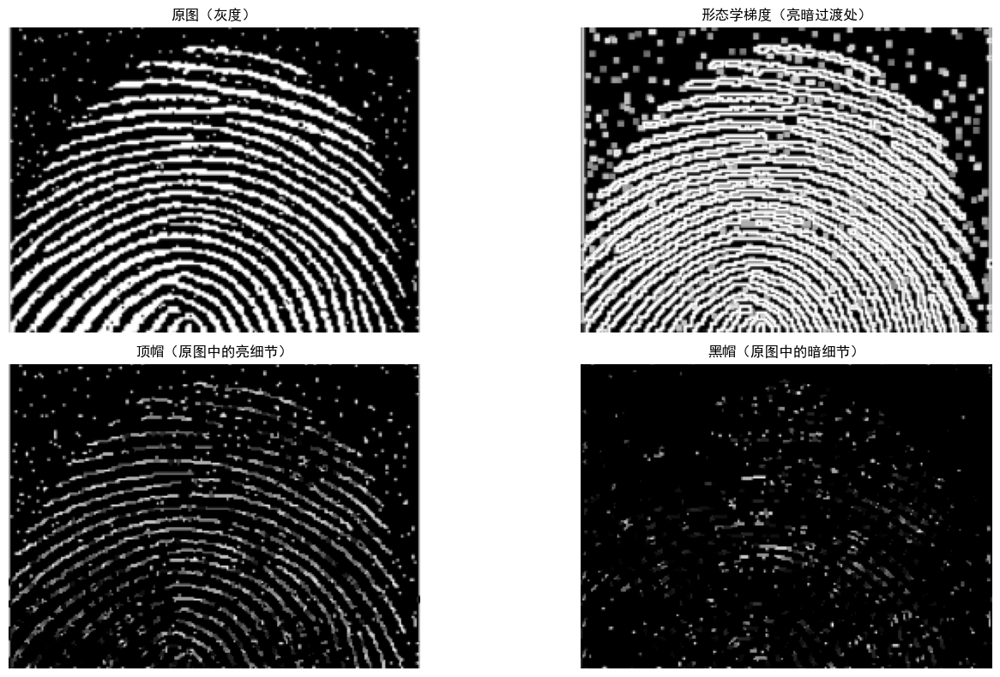

In [66]:
# ============ 2.14.4 实例：梯度、顶帽、黑帽（指纹演示） ============
# 本节完全独立：自己导入库、自己读取图像
# 注意：顶帽/黑帽作用在【灰度原图】上，不做二值化

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

# ---------- 第一步：读取原图（灰度），不做二值化 ----------
finger = cv2.imread('P&V/noisy-fingerprint.png', cv2.IMREAD_GRAYSCALE)  # 读灰度原图
assert finger is not None, '图像读取失败'                              # 检查
print('dtype（位深）:', finger.dtype)                                 # 位深
print('实际 min/max:', finger.min(), finger.max())                    # 实际值域
print('唯一值个数:', len(np.unique(finger)))                          # 灰度层次多少

# ---------- 第二步：形态学梯度 / 顶帽 / 黑帽（都作用在灰度原图上） ----------
kernel = np.ones((3, 3), np.uint8)                                  # 3x3 核

gradient = cv2.morphologyEx(finger, cv2.MORPH_GRADIENT, kernel)     # 梯度（亮暗过渡处）
tophat   = cv2.morphologyEx(finger, cv2.MORPH_TOPHAT,   kernel)     # 顶帽（原图里的亮细节）
blackhat = cv2.morphologyEx(finger, cv2.MORPH_BLACKHAT, kernel)     # 黑帽（原图里的暗细节）

# ---------- 第三步：可视化（第一张是原图，形成「输入 → 三种结果」对照） ----------
plt.figure(figsize=(15, 8))                                         # 画布

plt.subplot(2, 2, 1)                                                # 原图
plt.imshow(finger, cmap='gray')                                     # 显示
plt.title('原图（灰度）')                                           # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 2)                                                # 梯度
plt.imshow(gradient, cmap='gray')                                   # 显示
plt.title('形态学梯度（亮暗过渡处）')                                # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 3)                                                # 顶帽
plt.imshow(tophat, cmap='gray')                                     # 显示
plt.title('顶帽（原图中的亮细节）')                                  # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 4)                                                # 黑帽
plt.imshow(blackhat, cmap='gray')                                   # 显示
plt.title('黑帽（原图中的暗细节）')                                  # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

> **指纹形态学小结**：
>
- **腐蚀**：脊线变细，适合分离粘连的脊线；
- **膨胀**：脊线变粗，适合连接断裂的脊线；
- **开运算**：去除脊线周围的小白噪点；
- **闭运算**：填补脊线内部的小黑孔；
- **梯度**：提取脊线边缘；
- **顶帽**：提取脊线上的亮细节；
- **黑帽**：提取脊线间的暗细节。

---
# 2.15 结构元素

结构元素（kernel）决定了形态学操作的形状和大小。OpenCV 提供三种预定义形状：

- `MORPH_RECT`：矩形；
- `MORPH_ELLIPSE`：椭圆；
- `MORPH_CROSS`：十字。

```python
kernel = cv2.getStructuringElement(shape, ksize)
```

也可以自定义 NumPy 数组作为结构元素。

**在指纹处理中**：
- **矩形核**：最常用，对所有方向一视同仁；
- **椭圆核**：对圆形噪点更友好；
- **十字核**：对水平和垂直方向的脊线更友好。

dtype（位深）: uint8
实际 min/max: 0 255
唯一值个数: 193
→ Otsu 自动选定阈值 = 113.0


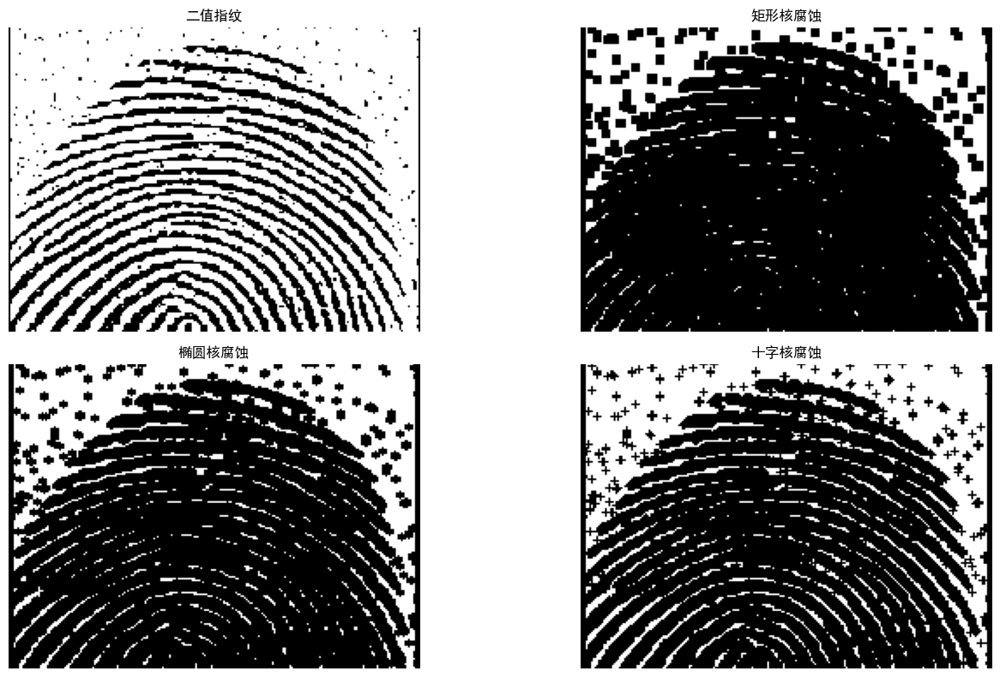

In [67]:
# ============ 2.15 实例：结构元素对比（指纹演示） ============
# 本节完全独立：自己导入库、自己读取图像、自己定阈值

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

# ---------- 第一步：看位深 ----------
finger = cv2.imread('P&V/noisy-fingerprint.png', cv2.IMREAD_UNCHANGED)    # 原样读取
assert finger is not None, '图像读取失败'                            # 检查
if finger.ndim == 3:                                                # 若是彩色
    finger = cv2.cvtColor(finger, cv2.COLOR_BGR2GRAY)               # 转灰度
print('dtype（位深）:', finger.dtype)                               # 位深
print('实际 min/max:', finger.min(), finger.max())                  # 实际值域

# ---------- 第二步：扫分布 ----------
uniq = np.unique(finger)                                            # 全部唯一值
print('唯一值个数:', len(uniq))                                     # 是否伪二值

# ---------- 第三步：定阈值 ----------
if len(uniq) <= 2:                                                  # 本来就是二值图
    finger_bin = finger.copy()                                      # 直接拿来用
else:                                                               # 需要切一刀
    # 形态学里希望白色是前景，所以用 OTSU + BINARY_INV
    ret, finger_bin = cv2.threshold(finger, 0, 255,
                                    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)  # 自动反二值化
    print(f'→ Otsu 自动选定阈值 = {ret:.1f}')                        # 查看 Otsu 选了多少

# ---------- 第四步：三种结构元素 + 腐蚀 ----------
rect = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))            # 矩形
ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))      # 椭圆
cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))          # 十字

eroded_rect = cv2.erode(finger_bin, rect)                           # 矩形腐蚀
eroded_ellipse = cv2.erode(finger_bin, ellipse)                     # 椭圆腐蚀
eroded_cross = cv2.erode(finger_bin, cross)                         # 十字腐蚀

plt.figure(figsize=(15, 8))                                         # 画布
plt.subplot(2, 2, 1)                                                # 原图
plt.imshow(finger_bin, cmap='gray')                                 # 显示
plt.title('二值指纹')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 2)                                                # 矩形
plt.imshow(eroded_rect, cmap='gray')                                # 显示
plt.title('矩形核腐蚀')                                             # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 3)                                                # 椭圆
plt.imshow(eroded_ellipse, cmap='gray')                             # 显示
plt.title('椭圆核腐蚀')                                             # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 4)                                                # 十字
plt.imshow(eroded_cross, cmap='gray')                               # 显示
plt.title('十字核腐蚀')                                             # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---
# 2.16 击中击不中变换

击中击不中变换（Hit-or-Miss）用于检测**特定形状**。它需要两个结构元素：
- `kernel1`：匹配前景；
- `kernel2`：匹配背景。

OpenCV 中：
```python
dst = cv2.morphologyEx(src, cv2.MORPH_HITMISS, kernel)
```

其中 `kernel` 包含 `1`（前景）、`-1`（背景）、`0`（不关心）。

**在指纹处理中**：击中击不中变换常用于检测**端点**和**分叉点**——这两种特征是指纹识别的关键。

---

## 2.16.1 它能不能检测「各种形状」，比如圆？

**可以，但有严格前提。** 击中击不中变换的本质是**模板匹配**，它只能检测**与模板完全一致**的形状。

以检测圆为例，你需要构造一个核：

- **内部（值为 1）**：一个圆盘；
- **外部（值为 -1）**：圆盘外围的一圈环，表示圆外面必须是背景；
- **不关心区域（值为 0）**：其余部分。

只有当图像中某个位置的像素分布**完全符合**这个模板时（模板为 1 处必须是前景，模板为 -1 处必须是背景），该位置才会被命中。

这意味着：

- 图像中有一个圆，但**大小**和模板不一样 → 检测不出；
- 圆的**粗细**（线宽）不同 → 检测不出；
- 圆周围有噪声（本该背景处出现前景）→ 检测失败；
- 圆与别的物体粘连 → 检测失败。

**换句话说：它检测的是「固定尺寸、固定边缘结构」的形状，而不是「任意大小的圆」。实际中很少用它直接检测“各种形状”**

## 2.16.2 那它还有什么意义？

如果它既不能适应不同大小，又对噪声敏感，实际中很少用它直接检测“各种形状”，为什么还会被写进教科书，并且 OpenCV 专门为它提供函数？

原因在于：**它的意义不在「找大形状」，而在「做极其精细的像素级特征提取和形态学骨架分析」。**

它不可替代的价值主要体现在下面几个场景：

### （1）细化与骨架分析：寻找端点、交叉点、角点

这正是本节指纹场景的核心用途。把一根粗线条（指纹纹路、血管、道路）通过形态学**细化（Thinning）**成只有 1 个像素宽的「骨架」后，如何找到骨架的端点（线头）和分叉点（三岔路口）？

- **端点**：周围只有 1 个相邻像素是前景；
- **分叉点**：周围有 3 个相邻像素是前景；
- **交叉点**：周围有 4 个相邻像素是前景。

这些特征都是**固定大小的 3×3 像素模式**。用击中击不中变换，只需定义几个极小的 3×3 模板，就能瞬间把整张图里所有的端点和分叉点精准提取出来。**用其他算法（如霍夫变换）来做这件事极其困难且不准确。**

### （2）像素级的精确拓扑关系检测（细化、剪枝）

击中击不中变换是数学形态学中**细化（Thinning）**和**剪枝（Pruning）**算法的底层核心。在细化算法中，需要判断一个像素是否可以被删除（即它是否属于边缘的冗余像素）。判断条件就是看该像素及其 8 邻域是否符合某种特定的「击中击不中」模板。通过不断迭代这些微小的模板，粗线条就能被均匀地「腐蚀」成单像素骨架。

### （3）检测固定尺寸的几何特征

虽然它不能检测任意大小的圆，但它非常适合检测**固定尺寸的特定结构**：

- **孤立点检测**：一个 3×3 的模板，中心为 1，周围 8 个全为 -1。可以用来在二值图像中精准剔除或定位孤立的噪点；
- **特定角点**：比如检测一个直角（L 型），或者一个十字交叉（+ 型），只需定义一个对应的 3×3 或 5×5 模板；
- **细化后的特定形状**：在工业视觉中，检测 PCB 板上的特定走线拐角，或者检测文本字符中的特定笔画（如汉字「十」字的交叉点）。

### （4）作为复杂形态学操作的「原子操作」

很多高级的形态学操作（如**形态学重建**、**测地膨胀**、**条件膨胀**）在底层实现时，都会用到击中击不中变换的思想。它提供了一种「如果满足 A 且不满足 B，则执行 C」的逻辑门机制，是构建复杂形态学算法的基石。

---

### 一句话总结它的定位

如果把图像处理比作做手术：

- **霍夫变换、模板匹配** 像 **B 超或 X 光**，用来找大块的肿瘤或器官（大形状、任意大小）；
- **击中击不中变换** 像 **显微手术刀**，用来做极其精细的神经缝合、剔除单个病变细胞（像素级、固定尺寸的拓扑特征）。

**它的意义在于「精准」和「拓扑」，而不是「通用」和「尺度不变」。** 当你处理的是已经二值化、且特征尺寸固定的图像（如指纹、骨架、字符笔画、PCB 走线）时，它就是无可替代的神器。

> **关于「它和霍夫变换该选哪个」的进一步对照，见附录 F。**

dtype（位深）: uint8
实际 min/max: 0 255
唯一值个数: 193
→ Otsu 自动选定阈值 = 113.0


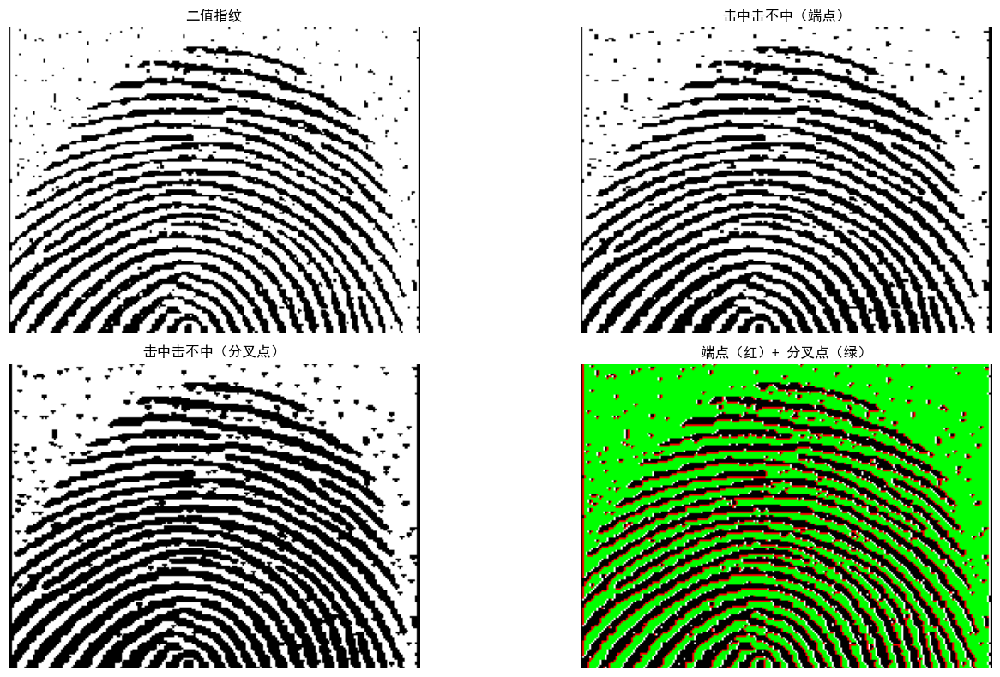

说明：
  端点核只匹配“右侧有邻居”的端点；实际工程中需要把 8 个方向模板都跑一遍再合并
  分叉点核匹配 T 型交叉；同样需要多方向模板合并
  这正是击中击不中的典型用法：像素级、固定尺寸、拓扑特征提取
  它能检测圆，但只能检测与模板尺寸完全一致的圆；通用圆检测请用霍夫变换


In [68]:
# ============ 2.16 实例：击中击不中变换（指纹演示） ============
# 本节完全独立：自己导入库、自己读取图像、自己定阈值

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

# ---------- 第一步：看位深 ----------
finger = cv2.imread('P&V/noisy-fingerprint.png', cv2.IMREAD_UNCHANGED)    # 原样读取
assert finger is not None, '图像读取失败'                            # 检查
if finger.ndim == 3:                                                # 若是彩色
    finger = cv2.cvtColor(finger, cv2.COLOR_BGR2GRAY)               # 转灰度
print('dtype（位深）:', finger.dtype)                               # 位深
print('实际 min/max:', finger.min(), finger.max())                  # 实际值域

# ---------- 第二步：扫分布 ----------
uniq = np.unique(finger)                                            # 全部唯一值
print('唯一值个数:', len(uniq))                                     # 是否伪二值

# ---------- 第三步：定阈值 ----------
if len(uniq) <= 2:                                                  # 本来就是二值图
    finger_bin = finger.copy()                                      # 直接拿来用
else:                                                               # 需要切一刀
    # 形态学里希望白色是前景，所以用 OTSU + BINARY_INV
    ret, finger_bin = cv2.threshold(finger, 0, 255,
                                    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)  # 自动反二值化
    print(f'→ Otsu 自动选定阈值 = {ret:.1f}')                        # 查看 Otsu 选了多少

# ---------- 第四步：定义端点核与分叉点核 ----------
# 端点核：中心为 1，只在一个方向上有前景邻居
kernel_endpoint = np.array([[0, 0, 0],                              # 第一行：不关心
                             [0, 1, 1],                             # 第二行：中心 1，右侧前景
                             [0, 0, 0]], dtype=np.int8)             # 第三行：不关心

# 分叉点核：中心为 1，且三个方向有前景邻居（T 型）
kernel_branch = np.array([[0, 1, 0],                                # 第一行：上方前景
                           [1, 1, 1],                               # 第二行：左、中、右前景
                           [0, 0, 0]], dtype=np.int8)               # 第三行：不关心

# 说明：如果要检测“任意方向”的端点，需要把多个方向的模板都跑一遍，再做或运算

# ---------- 第五步：击中击不中 ----------
hitmiss_endpoint = cv2.morphologyEx(finger_bin, cv2.MORPH_HITMISS, kernel_endpoint)  # 端点
hitmiss_branch = cv2.morphologyEx(finger_bin, cv2.MORPH_HITMISS, kernel_branch)      # 分叉点

plt.figure(figsize=(15, 8))                                         # 画布
plt.subplot(2, 2, 1)                                                # 二值图
plt.imshow(finger_bin, cmap='gray')                                 # 显示
plt.title('二值指纹')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 2)                                                # 端点
plt.imshow(hitmiss_endpoint, cmap='gray')                           # 显示
plt.title('击中击不中（端点）')                                     # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 3)                                                # 分叉点
plt.imshow(hitmiss_branch, cmap='gray')                             # 显示
plt.title('击中击不中（分叉点）')                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(2, 2, 4)                                                # 叠加到原图
overlay = cv2.cvtColor(finger_bin, cv2.COLOR_GRAY2BGR)              # 转 BGR
overlay[hitmiss_endpoint > 0] = (0, 0, 255)                         # 端点标红
overlay[hitmiss_branch > 0] = (0, 255, 0)                           # 分叉点标绿
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))                # 显示
plt.title('端点（红）+ 分叉点（绿）')                                # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

print('说明：')                                                      # 说明
print('  端点核只匹配“右侧有邻居”的端点；实际工程中需要把 8 个方向模板都跑一遍再合并')  # 说明第一行
print('  分叉点核匹配 T 型交叉；同样需要多方向模板合并')                # 说明第二行
print('  这正是击中击不中的典型用法：像素级、固定尺寸、拓扑特征提取')    # 说明第三行
print('  它能检测圆，但只能检测与模板尺寸完全一致的圆；通用圆检测请用霍夫变换')  # 说明第四行

---
# 2.17 自定义滤波 filter2D

`cv2.filter2D` 允许你用**自定义核**做卷积/相关。

```python
dst = cv2.filter2D(src, ddepth, kernel)
```

- `ddepth`：输出深度，`-1` 表示与原图相同；
- `kernel`：自定义核（NumPy 数组）。

**在指纹处理中**：自定义核可以用于脊线增强、方向滤波等。

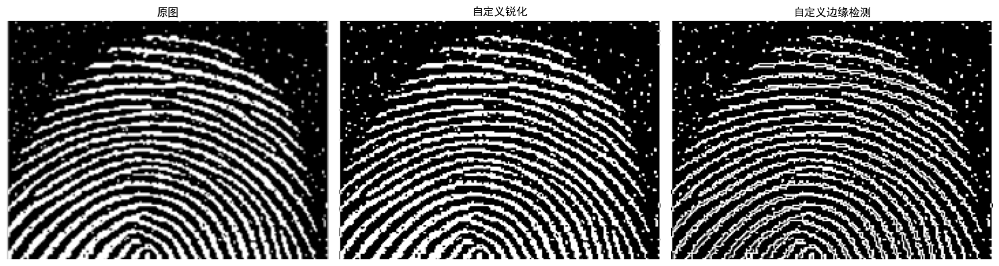

In [69]:
# ============ 2.17 实例：自定义滤波 filter2D（指纹演示） ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

finger = cv2.imread('P&V/noisy-fingerprint.png', cv2.IMREAD_GRAYSCALE)    # 读取
assert finger is not None, '图像读取失败'                            # 检查

# 自定义锐化核
kernel_sharp = np.array([[0, -1, 0],                                # 第一行
                          [-1, 5, -1],                              # 第二行
                          [0, -1, 0]], dtype=np.float32)            # 第三行
sharp = cv2.filter2D(finger, -1, kernel_sharp)                      # 锐化

# 自定义边缘检测核
kernel_edge = np.array([[-1, -1, -1],                               # 第一行
                         [-1, 8, -1],                               # 第二行
                         [-1, -1, -1]], dtype=np.float32)           # 第三行
edge = cv2.filter2D(finger, -1, kernel_edge)                        # 边缘

plt.figure(figsize=(15, 4))                                         # 画布
plt.subplot(1, 3, 1)                                                # 原图
plt.imshow(finger, cmap='gray')                                     # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 3, 2)                                                # 锐化
plt.imshow(sharp, cmap='gray')                                      # 显示
plt.title('自定义锐化')                                             # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 3, 3)                                                # 边缘
plt.imshow(edge, cmap='gray')                                       # 显示
plt.title('自定义边缘检测')                                         # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

---

# 2.18 卷积和相关运算

## 2.18.1 这个运算能做什么？

卷积/相关是图像处理里**最基础、最通用的运算之一**。它的形式很简单——**一个小核在图像上滑动，每滑到一个位置就把核覆盖的区域做加权求和，结果写到输出图对应的像素上**——但用途极其广泛。

一个核，就是一个「**作用规则**」。你设计不同的核，就得到不同的效果：

| 用途 | 典型核 | 效果 |
|------|--------|------|
| **平滑 / 去噪** | 均值核、高斯核 | 每个像素取邻域平均，噪声被抹平 |
| **锐化 / 增强细节** | 拉普拉斯核、自定义锐化核 | 突出像素与邻域的差异，细节变清晰 |
| **边缘检测** | Sobel 核、Prewitt 核、Laplacian 核 | 提取灰度剧烈变化的位置，得到轮廓 |
| **特征增强** | Gabor 核、方向滤波核 | 强化某个方向的纹理，如指纹脊线 |
| **模板匹配** | 与目标形状一致的核 | 找图中和核最相似的位置 |
| **深度学习特征提取** | 训练学出来的核 | 自动学习对任务有用的局部模式 |

**一句话总结它的作用**：

> **卷积/相关 = 用一个核，把图像里「某种局部模式」提取、增强或抑制出来。**

你设计什么样的核，就得到什么样的效果。它本身不是目的，而是**实现各种图像处理效果的一个统一工具**——平滑、锐化、边缘检测、特征增强、模板匹配，都是这一个运算加上不同的核。

### 为什么它这么重要

- **统一**：平滑、锐化、边缘……看起来是不同操作，底层是同一个运算，只是核不同；
- **局部**：它只看每个像素的邻域，天然适合处理图像的局部结构（边缘、纹理、角点）；
- **可组合**：多个核可以串联，形成更复杂的处理流程；
- **可学习**：核不一定要人工设计——深度学习的卷积层就是让机器自己学出这些核。

---



## 2.18.2 OpenCV 里做这件事的函数只有一个

先看清楚 OpenCV 到底提供了什么。做「滑动窗口乘加」这件事，OpenCV 里**只有一个函数**：

```python
dst = cv2.filter2D(src, ddepth, kernel)
```

没有 `cv2.correlate2D`，也没有 `cv2.convolve2D`——就这一个。

它的行为是：**拿你传进去的 `kernel` 直接在 `src` 上滑动，逐位置做乘加，输出到 `dst`。**

**关键**：它拿到什么核就用什么核，**不会替你翻转核**，也不会问你「你想做卷积还是相关」。

所以，从 OpenCV 使用者的视角看：

> **「卷积/相关」不是两个函数，而是同一个 `filter2D` 的两种用法**——取决于你传进去的核翻没翻。

### 两种用法对照

| 你想做 | 怎么写代码 | 函数签名变了吗 |
|--------|------------|----------------|
| **相关** | `cv2.filter2D(src, -1, K)` | 不变 |
| **卷积** | `cv2.filter2D(src, -1, np.flip(K))` | 不变 |

**函数签名完全一样**，你只是把 `kernel` 这个参数位换了个值。

下面这段代码把两种用法并排跑一遍：

```python
corr = cv2.filter2D(test, -1, kernel)              # 相关：传原核
conv = cv2.filter2D(test, -1, np.flip(kernel))     # 卷积：传翻转核
```

调用的是同一个函数——只是 `kernel` 参数不同。

> **注意**：OpenCV **不帮你翻核**。`filter2D` 拿到什么核就用什么核，翻转这件事**完全落在用户头上**。想做卷积，必须自己 `np.flip`。

---



## 2.18.3 那「卷积」和「相关」到底差在哪？

上面说了 OpenCV 里只有一个函数、两种用法。那这两种用法背后，到底对应什么数学差异？

**卷积**（Convolution）和**相关**（Correlation）是两个**不同的数学运算**，区别只在于**核是否翻转**：

- **相关**（Correlation）：核**不翻转**，直接滑动乘加；
- **卷积**（Convolution）：核**先翻转 180°**，再滑动乘加。

### 用一个小例子看清区别

假设输入信号 `[1, 2, 3]`，核 `[a, b, c]`：

**相关（不翻核）**：

```
信号：  1   2   3
核：    a   b   c
结果：  1a + 2b + 3c
```

**卷积（翻核）**：

```
信号：  1   2   3
翻转核：c   b   a
结果：  1c + 2b + 3a
```

**同样的信号、同样的核，结果不一样**——因为核被翻了。

### 对应回 OpenCV

| 数学运算 | 核 | OpenCV 里怎么写 |
|----------|-----|----------------|
| **相关** | 不翻 | `filter2D(src, -1, K)` |
| **卷积** | 翻 180° | `filter2D(src, -1, np.flip(K))` |

也就是说：

> **`cv2.filter2D` 默认做的是相关**（核不翻）；
> **想做卷积，需要用户自己先 `np.flip(kernel)`**。

---



## 2.18.4 什么时候两者结果一样？

看核是否**对称**：

| 核类型 | 是否对称 | 相关 == 卷积？ |
|--------|----------|----------------|
| 均值核（全 1） | 对称 | ✅ 一样 |
| 高斯核 | 对称 | ✅ 一样 |
| 拉普拉斯核 | 对称 | ✅ 一样 |
| 锐化核 | 对称 | ✅ 一样 |
| Sobel 核 | **不对称** | ❌ 不一样 |
| 手写的非对称核 | **不对称** | ❌ 不一样 |

**对于常用的平滑/锐化核，翻不翻转没区别**——这就是为什么很多人没注意到这个区别。但只要核不对称，两者立刻分道扬镳。

---



## 2.18.5 和深度学习的关系

深度学习里的「卷积层」，和 OpenCV 的 `filter2D` 是什么关系？

| 库 | 是否自动翻核 | 实际做的是 |
|----|----------------|-----------|
| **OpenCV `filter2D`** | ❌ 不翻 | 用户决定：相关或卷积 |
| **PyTorch `nn.Conv2d`** | ❌ 不翻 | 永远是**相关** |
| **TensorFlow `tf.nn.conv2d`** | ❌ 不翻 | 永远是**相关** |

**结论**：

- 深度学习里的「卷积」，**严格来说做的是相关**（不翻核）；
- 所以 **OpenCV 的相关 = 深度学习的「卷积」**，数值上一致（忽略边界处理差异）；
- **OpenCV 的卷积（翻核）= 数学教科书上的卷积**，和深度学习不同。

### 一个容易混淆的点：运算维度 vs 核来源

「卷积/相关」和「手工核/学出来的核」是**两个独立维度**，不要混在一起：

| 维度 | OpenCV `filter2D` | 深度学习卷积层 |
|------|-------------------|----------------|
| **运算** | 相关（默认）或卷积（翻核） | 相关（不翻） |
| **核来源** | 人工设计 | 通过反向传播学出来 |
| **核是否更新** | 固定 | 训练中不断更新 |
| **通道处理** | 逐通道独立 | 跨通道融合（`C_in → C_out`） |

**关键区分**：

- **「卷积还是相关」** 是数学定义问题（核翻不翻）；
- **「手工还是学出来」** 是工程实现问题（核从哪来）；
- **「逐通道还是跨通道」** 是工程实现问题（通道维度怎么处理）。

三者是**独立的三件事**，不要混在一起。

---



## 2.18.6 一句话总记

> **作用**：用一个核，把图像里某种局部模式提取、增强或抑制出来——平滑、锐化、边缘检测都靠它。
>
> **OpenCV 只有一个 `filter2D`，不做翻转判断。**
> **传原核 = 相关；传翻转核 = 卷积。**
> **对称核下二者一样，非对称核下结果不同。**
> **深度学习里的「卷积」严格来说是相关。**

> **完整对照**：卷积/相关的数学定义、为什么主流库都不翻核、和深度学习 `Conv2d` 的详细关系，**见附录 G**。

**卷积**和**相关**是两种相似的运算，区别在于**核是否翻转**：

- **相关**：核不翻转，直接滑动乘加；
- **卷积**：核先翻转 180°，再滑动乘加。

对于**对称核**（如均值核、高斯核），两者结果相同；对于**非对称核**（如锐化核、Sobel 核），两者结果不同。

OpenCV 的 `cv2.filter2D` 默认计算的是**相关**，不是卷积！如果要计算真正的卷积，需要手动翻转核。

测试图像：
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
非对称核：
 [[0. 0. 0.]
 [0. 0. 1.]
 [0. 0. 0.]]


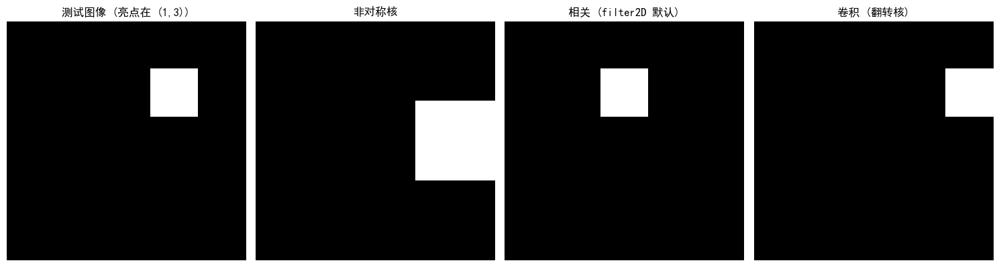

相关结果：
 [[0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
卷积结果：
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
观察：相关和卷积的结果不同！


In [70]:
# ============ 2.18 实例：卷积与相关的区别 ============
# 本节完全独立：自建测试数据

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

# 创建 5x5 测试图像
test = np.zeros((5, 5), dtype=np.float32)                           # 全零
test[1, 3] = 1.0                                                    # 设置一个亮点
print('测试图像：\n', test)                                        # 打印

# 非对称核
kernel = np.array([[0, 0, 0],                                       # 核第一行
                    [0, 0, 1],                                       # 核第二行：非对称
                    [0, 0, 0]], dtype=np.float32)                    # 核第三行
print('非对称核：\n', kernel)                                       # 打印核

# 相关（filter2D 默认）
correlation = cv2.filter2D(test, -1, kernel, borderType=cv2.BORDER_CONSTANT)  # 相关

# 卷积（手动翻转核）
kernel_flipped = np.flip(kernel)                                    # 翻转核
convolution = cv2.filter2D(test, -1, kernel_flipped, borderType=cv2.BORDER_CONSTANT)  # 卷积

plt.figure(figsize=(15, 4))                                         # 画布
plt.subplot(1, 4, 1)                                                # 测试图像
plt.imshow(test, cmap='gray')                                       # 显示
plt.title('测试图像 (亮点在 (1,3))')                                # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                # 核
plt.imshow(kernel, cmap='gray')                                     # 显示
plt.title('非对称核')                                               # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                # 相关
plt.imshow(correlation, cmap='gray')                                # 显示
plt.title('相关 (filter2D 默认)')                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                # 卷积
plt.imshow(convolution, cmap='gray')                                # 显示
plt.title('卷积 (翻转核)')                                          # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

print('相关结果：\n', correlation)                                 # 打印相关
print('卷积结果：\n', convolution)                                 # 打印卷积
print('观察：相关和卷积的结果不同！')                                # 观察

---
# 2.19 图像配准 findTransformECC

图像配准是找到两张图像之间的**空间变换关系**。OpenCV 提供了 `cv2.findTransformECC`，使用**增强相关系数（ECC）**作为相似度度量。

```python
cc, warp_matrix = cv2.findTransformECC(template, input, warp_matrix,
                                        motion_type, criteria)
```

- `template`：模板图（参考图）；
- `input`：待配准图；
- `warp_matrix`：初始变换矩阵；
- `motion_type`：`MOTION_TRANSLATION`、`MOTION_EUCLIDEAN`、`MOTION_AFFINE`、`MOTION_HOMOGRAPHY`；
- `criteria`：迭代终止条件。

ECC 相关系数: 0.9957260227723087
估计的变换矩阵：
 [[  1.         0.        15.280919]
 [  0.         1.       -10.169187]]
真实的变换矩阵：
 [[  1.   0.  15.]
 [  0.   1. -10.]]


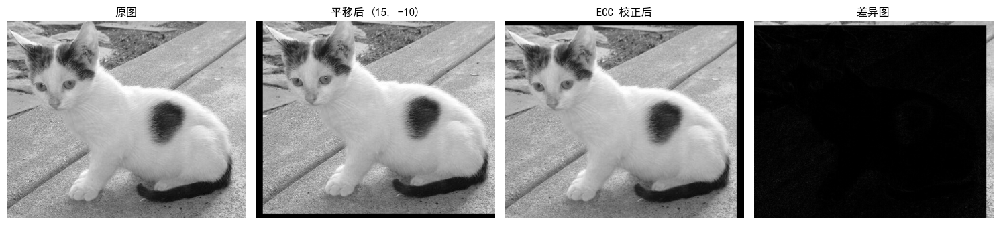

In [71]:
# ============ 2.19 实例：图像配准 findTransformECC ============
# 本节完全独立：自己导入库、自己读取图像

import cv2                                                          # 导入 OpenCV
import numpy as np                                                  # 导入 NumPy
import matplotlib.pyplot as plt                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                          # 负号

img = cv2.imread('P&V/cat.jpg', cv2.IMREAD_GRAYSCALE)               # 读取灰度图
assert img is not None, '图像读取失败'                               # 检查
h, w = img.shape[:2]                                                # 高宽

# 构造一个已知的平移
true_shift = np.float32([[1, 0, 15],                                # 真实平移矩阵第一行
                          [0, 1, -10]])                             # 真实平移矩阵第二行
shifted = cv2.warpAffine(img, true_shift, (w, h))                   # 平移后的图像

# 用 findTransformECC 估计平移
warp_matrix = np.eye(2, 3, dtype=np.float32)                        # 初始变换矩阵（单位阵）
criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 100, 1e-5)  # 终止条件
cc, estimated_warp = cv2.findTransformECC(img, shifted, warp_matrix,
                                           cv2.MOTION_TRANSLATION, criteria)  # 估计变换
print('ECC 相关系数:', cc)                                          # 打印相关系数
print('估计的变换矩阵：\n', estimated_warp)                         # 打印估计矩阵
print('真实的变换矩阵：\n', true_shift)                             # 打印真实矩阵

# 用估计的矩阵校正
aligned = cv2.warpAffine(shifted, estimated_warp, (w, h),
                          flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)  # 校正

plt.figure(figsize=(15, 4))                                         # 画布
plt.subplot(1, 4, 1)                                                # 原图
plt.imshow(img, cmap='gray')                                        # 显示
plt.title('原图')                                                   # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                # 平移后
plt.imshow(shifted, cmap='gray')                                    # 显示
plt.title('平移后 (15, -10)')                                       # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                # 校正后
plt.imshow(aligned, cmap='gray')                                    # 显示
plt.title('ECC 校正后')                                             # 标题
plt.axis('off')                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                # 差异图
diff = cv2.absdiff(img, aligned)                                    # 差异
plt.imshow(diff, cmap='gray')                                       # 显示
plt.title('差异图')                                                 # 标题
plt.axis('off')                                                     # 关闭坐标轴
plt.tight_layout()                                                  # 调整
plt.show()                                                          # 渲染

**为什么差异图几乎全黑？**

因为 ECC 校正的目的就是把「平移后的图」拉回到和「原图」对齐。校正成功后，`aligned` 和 `img` 应该**几乎完全一致**，所以 `absdiff` 出来的结果接近 0（全黑）。

图中还能隐约看到一点轮廓，是因为：

- **平移是整数像素（15, -10），但 ECC 估计出的变换可能有亚像素误差**；
- **`warpAffine` 用了双线性插值**，边缘像素会被重新加权，和原图不是逐像素严格相等；
- 边界区域（平移后露出的黑边）和原图对应位置不同。

所以差异图**越黑，说明配准越准**。这张图基本全黑，说明 ECC 的配准效果很好。

---
# 附录

本附录按**正文中首次出现的顺序**编排。

- **附录 A**：Otsu 的全称与由来（首次出现在 2.10）
- **附录 B**：阈值化的三步流程（首次出现在 2.10、2.14.2）
- **附录 C**：二值图到底是不是「只有 0 和 255」（首次出现在 2.14.1）
- **附录 D**：为什么形态学总说「白色区域」变大变小（首次出现在 2.14.1）
- **附录 E**：开运算与闭运算的名字从哪来（首次出现在 2.14.3）
- **附录 F**：击中击不中变换的定位——为什么它不追求「通用形状」（首次出现在 2.16）

## 附录 A：Otsu 的全称与由来

**Otsu** 是**日本人名**，不是缩写，所以它**没有「全称」**——就是一个姓氏。

| 项目 | 内容 |
|------|------|
| 日文原名 | **大津 展之**（おおつ のぶゆき） |
| 罗马字 | **Nobuyuki Otsu** |
| 中文常译 | 大津展之 |
| 算法名 | **Otsu's method**（大津法 / 大津阈值法） |
| 提出年份 | 1979 年 |
| 论文 | *A Threshold Selection Method from Gray-Level Histograms* |

所以「Otsu」**不是** `Optimal Threshold Selection Utility` 之类的缩写；**就是**算法提出者 **大津展之（Otsu）** 的姓氏。中文里叫 **「大津法」** 或 **「大津阈值法」**，英文叫 **Otsu's method**。

### A.1 一句话

> **Otsu = 大津展之的姓**，算法全称是 **「大津阈值法」（Otsu's method）**，不是缩写。

## 附录 B：阈值化的三步流程（看位深 → 扫分布 → 定阈值）

正文 2.14.2 起各节代码块，二值化都按同一套流程处理。这套流程的出发点很简单：**动手写阈值之前，先看清图到底是什么**。

### B.1 三步流程

| 步骤 | 目的 | 看什么 | 手段 |
|------|------|--------|------|
| **① 看位深** | 知道值域上限（0~15？0~255？0~65535？） | `img.dtype` | `IMREAD_UNCHANGED` 读入 |
| **② 扫分布** | 知道值实际聚成几堆、堆在哪 | 直方图 / `np.unique` | `cv2.calcHist`、`np.unique` |
| **③ 定阈值** | 在两类之间切一刀 | 谷底位置 | 手填 or Otsu |

### B.2 逐阶段说明

**① 看位深——决定「尺子」的量程**

位深决定值域，值域决定阈值**能不能落进去**。

- 4 位 → 值域 0~15，阈值只能在 0~15 里选；
- 8 位 → 0~255；
- 16 位 → 0~65535。

这一步不看内容，只看「尺子有多长」。

**② 扫分布——决定「切在哪」**

看直方图 / 唯一值，判断：

- 是**双峰**（前景背景各一堆，中间空）→ 能切，切在谷底；
- 是**单峰**（全挤在一起）→ 切不出干净二值；
- 是**纯二值**（只有两个值）→ 根本不用切。

这一步不看值域端点，看的是**值的聚集形态**。

**③ 定阈值——两种合法做法**

- **手填**：②看过分布后，挑谷底位置填进去；
- **Otsu**：②不用你手动看，算法自己扫直方图找谷底，`thresh` 填 `0` 当占位符。

两条路都建立在「已经确认这是张待二值的图」之上。

### B.3 对应到代码

```python
_, finger_bin = cv2.threshold(finger, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```

- ① **没做**——直接假设了 8 位；
- ② **交给了 Otsu**——算法内部自己扫；
- ③ **由 Otsu 决断**——`0` 是占位符，`255` 是前景色。

所以这段代码是**跳过①②、把②③打包给 Otsu**。它偷懒但合法，前提是「图确实是 8 位且双峰可分」——这两个前提没验证，属于**约定俗成地假设成立**。

### B.4 最严谨的流程

> **先看位深（①）→ 再扫分布（②）→ 最后定阈值（③）**

这是**最严谨**的流程。相比直接用 Otsu，多的就是①和②两步人工确认——换来的是**不依赖任何隐含假设**，任何图拿来都能正确处理。

实际写代码时，通用函数走这个完整流程；教学示例图省事，往往只留③（还常常硬编码 127，连 Otsu 都省了）。

### B.5 Otsu 的适用条件和局限

**适用**：

- 8 位单通道灰度图（`uint8`）；
- 直方图**双峰明显**（前景背景各一堆，中间有谷底）——比如指纹、文字扫描件、细胞图；
- 光照比较均匀。

**不适用**：

- **单峰图**：全部像素挤在一起，没有「两类」可分，Otsu 会硬切一刀，结果没意义；
- **多峰图**：有三类以上（比如图里同时有背景、暗物体、亮物体），Otsu 只会切成两类，分不干净；
- **光照不均**：同一类物体在不同区域亮度差很多，一个全局阈值切不好——这时要用**自适应阈值** `cv2.adaptiveThreshold`；
- **彩色图**：Otsu 只对单通道有效，彩色图要先转灰度。

## 附录 C：二值图到底是不是「只有 0 和 255」

正文里常写「二值图像（只有 0 和 255 两种值）」。这个说法**基本没错，但不够准确**——它把「两种值」写成了「0 和 255」，等于把**一个特例当成了定义**。

### C.1 问题在哪

**二值图的定义是「只有两种值」，不是「只有 0 和 255」。**

「0 和 255」只是**最常见的一种取值约定**，不是二值图的本质。

### C.2 二值图实际可能长什么样

| 取值 | 出现场景 |
|------|----------|
| `{0, 255}` | OpenCV 二值化的默认输出，最常见 |
| `{0, 1}` | 逻辑掩码、NumPy bool 数组、某些库的约定 |
| `{False, True}` | Python 布尔数组 |
| `{0, 128}` | 某些系统前景用灰 128 而非纯白 |
| `{1, 2}` | 标签图（label image）里两个类别的编号 |

**它们的共同点是「两种值」，而不是「0 和 255」。**

### C.3 为什么二值形态学对「两种值」都成立

看腐蚀/膨胀在二值上的定义：

- **腐蚀**：邻域内有「背景值」→ 中心变「背景值」；
- **膨胀**：邻域内有「前景值」→ 中心变「前景值」。

这里只用到**「哪一种是前景、哪一种是背景」**，跟具体数值是 0/255 还是 0/1 **无关**。所以二值形态学只要求**两种值**，不要求**必须是 0 和 255**。

### C.4 更准确的说法

原句：

> 形态学最常用于**二值图像**（只有 0 和 255 两种值）

应改成：

> 形态学最常用于**二值图像**（只有两种值，通常取 0 和 255）

或更严谨：

> 形态学最常用于**二值图像**——像素只有两种取值（常见约定是 0 和 255，但也可以是 0 和 1 等）。

## 附录 D：为什么形态学总说「白色区域」变大变小

有人会问：为什么腐蚀/膨胀的描述**只提白色**，黑色被晾在一边？这不是「白色特殊」，而是**约定俗成的前景/背景设定**决定的。

### D.1 根源：形态学里有一个「前景」约定

形态学操作在二值图上，总要先确定**哪一种是「物体」，哪一种是「背景」**：

- **前景 = 物体 = 我们关心的东西**（通常是白色，值 255）；
- **背景 = 不需要处理的部分**（通常是黑色，值 0）。

腐蚀/膨胀描述的是**前景（白色）**的变化——因为**你真正关心的就是前景**。背景怎么变，是前景变化的副产品，不需要单独说。

### D.2 为什么默认是白色当前景

纯粹是**约定**，而且这个约定很自然：

| 原因 | 说明 |
|------|------|
| **打印/显示的直觉** | 把要处理的对象涂成白色更醒目 |
| **OpenCV 阈值化默认** | `THRESH_BINARY` 把「大于阈值的像素」设成 255（白），通常就是前景 |
| **找轮廓/连通域的前置** | `cv2.findContours` 找的是**白色**连通区域的轮廓 |
| **掩码（mask）的惯例** | 掩码里 255 = 选中、0 = 不选——选中区域就是白 |

所以**白 = 前景**，是整条图像处理链上的惯例，不是形态学自己的规定。

### D.3 如果前景是黑色会怎样

**完全可以**——只是所有描述要反过来。做法是**反色**：

```python
# 假设原始图里物体是黑的、背景是白的
inv = cv2.bitwise_not(img)      # 反色：黑变白，白变黑
# 现在物体是白的，可以按惯例用形态学
eroded = cv2.erode(inv, kernel)
```

或者在二值化时直接用 `THRESH_BINARY_INV`，把前景直接弄成白色。

**关键点**：形态学本身不关心「白还是黑」，它只处理「前景值 vs 背景值」。把前景弄成白色只是为了让操作语义跟通用惯例对齐。

### D.4 换一个角度：其实是在说「前景」

把「白色」换成「前景」，描述就通用了：

| 操作 | 通用描述 | 白色前景时 |
|------|---------|-----------|
| 腐蚀 | 前景**收缩** | 白变小 |
| 膨胀 | 前景**扩张** | 白变大 |

这样就不依赖颜色了——**腐蚀 = 前景收缩，膨胀 = 前景扩张**。当约定前景是白时，才写成「白变小/变大」。

**记住通用版**：腐蚀 = 前景收缩，膨胀 = 前景扩张。**颜色只是约定，前景才是本质。**

## 附录 E：开运算与闭运算的名字从哪来

「开」「闭」这两个名字确实不好记——听起来跟「腐蚀」「膨胀」没直接关系。但如果知道它们借的是**几何拓扑里的术语**，就通了。

### E.1 名字的真正来源：拓扑学里的「开集 / 闭集」

「开运算」和「闭运算」的英文是：

- **Opening**（开）
- **Closing**（闭）

这两个词来自数学里的**拓扑学**——在拓扑中有一对概念叫「**开集**（open set）」和「**闭集**（closed set）」。形态学把它们借过来，是因为这两个运算在几何上分别对应「**把物体打开、清除边缘毛刺**」和「**把物体封闭、填补内部缝隙**」。

所以名字的直觉不是「开 = 打开某物」，而是：

| 运算 | 字面直觉 |
|------|----------|
| Opening（开） | 把物体**「打开」**——削掉外伸的毛刺，让轮廓更干净 |
| Closing（闭） | 把物体**「封闭」**——填上内部的孔洞和裂缝 |

### E.2 为什么这两个词配这两种操作

再看它们的构成：

- **开运算 = 先腐蚀，后膨胀**（Erode → Dilate）
- **闭运算 = 先膨胀，后腐蚀**（Dilate → Erode）

名字取的其实是**「最终效果」**，不是「执行顺序」。

#### 开运算为什么叫「开」

- 先腐蚀：把物体边缘削进去一圈；
- 后膨胀：再把削进去的圈补回来。

但**削掉的东西补不回来**——那些比结构元素还细的**外伸毛刺、小突起、孤立噪点**，在腐蚀时被彻底消灭，膨胀时没有源可恢复。

结果：物体轮廓变**干净、平滑**，像是被「**打开、修剪**」过。

```
毛刺原样:       开运算后:
   █              █
  ███            ███
 █████          █████
   █              █
  █              （毛刺被削掉）
```

#### 闭运算为什么叫「闭」

- 先膨胀：把物体边缘向外扩一圈，**顺便把小孔、裂缝糊住**；
- 后腐蚀：再把外扩的圈收回来。

但**糊住的小孔**——那些比结构元素还小的**内部黑点、细缝**，在膨胀时被填满，腐蚀时没有「洞」可恢复。

结果：物体内部变**完整、闭合**，像是被「**封闭、补漏**」过。

```
有小孔原样:     闭运算后:
 █████          █████
 ██ ██          █████   （孔被填满）
 █████          █████
```

### E.3 关键：换一个视角看这两个操作

通常我们理解形态学是「**kernel 滑过图像**」。但「开/闭」这对名字，其实是站在**kernel 的角度**看。

想象你把 kernel 看作一个**探针/尺子**，让它滑过整个图像，问一个问题：

> **这个 kernel 能不能「整个塞进」白色区域里？**

#### 腐蚀 = 收缩允许的位置

**腐蚀**的含义是：

> 只有当 kernel 能**完全放进**白色区域里，中心点才保留。

效果：白色区域被**削掉**「kernel 塞不进」的那些位置——边缘、毛刺、细突起全被削掉，**剩下的都是「kernel 能完整容身」的地方**。

#### 膨胀 = 向外扩出位置

**膨胀**的含义是：

> 只要 kernel 覆盖到的范围内**有白色**，中心点就变白。

效果：白色区域**向外扩张**一圈。

#### 把两步连起来看「开」

开运算 = **先腐蚀，后膨胀**：

1. **腐蚀**：把所有「kernel 塞不进」的白色部分（外伸毛刺、孤立小点）**扔掉**；
2. **膨胀**：把剩下的白色**再长回来**一圈。

注意：**膨胀只能让「腐蚀后剩下的白色」长大**——那些在腐蚀阶段就被扔掉的毛刺，**没有源可恢复**，所以回不来。

**最终效果**：

> 图像里只剩下那些**「能被 kernel 完整容身」的白色区域**，并且它们**恢复到了原本大小**。

#### 那「开」到底开的是什么

> **Opening（开）= 只保留「kernel 能塞进去」的白色区域。**

「开」这个字，取的正是**「kernel 能开口、能容身」**的意思：

- kernel **能塞进去**的区域 → 保留；
- kernel **塞不进去**的区域（太细、太窄、太尖）→ 被削掉。

就像把 kernel 当成一个「**开口的模具**」——只有比模具大的东西才能通过、保留下来。

#### 换种说法验证

> **开运算 = 所有「能被结构元素完整包含的白色区域」的并集。**

这句话读起来绕，但意思就是：

- 用小刷子（kernel）在白色区域里**到处刷**，能刷到的地方才算数；
- 刷不到的细缝、尖角、小突起 → **不算数，被删掉**。

这就是「开」——**把 kernel 能「开进去」的部分挑出来**。

#### 闭运算对称理解

对照地看闭运算（**先膨胀后腐蚀**）：

> **Closing（闭）= 只保留「kernel 塞不进的黑色区域」都被填掉的结果。**

- 膨胀：kernel 一碰到黑色就把它涂白 → 小孔、细缝被**糊住**；
- 腐蚀：再把白边收回 → 糊住的小孔**填不回来**（因为它本来就是个洞）；
- 最终：**所有「kernel 塞不进的黑色区域」都被填掉了**。

「闭」取的正是「**把 kernel 塞不进的缝都闭合掉**」的意思。

### E.4 对照表与一句话总结

| 运算 | 顺序 | 取名字的视角 | 名字含义 |
|------|------|-------------|----------|
| **开 (Opening)** | 先腐蚀后膨胀 | 看**白色区域** | 只留「kernel 能**开进去、容得下**」的白色 |
| **闭 (Closing)** | 先膨胀后腐蚀 | 看**黑色区域** | 把「kernel **塞不进的**小缝」都**闭掉** |

**名字取的是最终效果，不是执行顺序：**

> **开（Opening）= 修剪外表**：先腐蚀削掉毛刺，再膨胀恢复主体——**只削外，不补内**。
> **闭（Closing）= 补全内部**：先膨胀填上孔洞，再腐蚀收边——**只补内，不削外**。

### E.5 一种速记理解：看黑区的变化

除了从「名字来源」理解，还有一种**结果速记**方式：看最终**黑色区域**的变化。

| 运算 | 两步组合 | 对黑区的净效果 |
|------|----------|----------------|
| 开 | 先腐蚀后膨胀 | 黑区**变大**（削掉的白毛刺变成了黑） |
| 闭 | 先膨胀后腐蚀 | 黑区**变小**（填掉的黑孔变成了白） |

也就是：**开让黑区变大，闭让黑区变小**。

#### 这个记法的适用边界

作为**区分开与闭的尺子**，它成立：

- 拿开和闭对比：黑变大的是开，黑变小的是闭 ✅

但**不能**拿它去和「单步腐蚀 / 单步膨胀」比——那两组会造成同样的黑区变化，就区分不出来了：

- **单步腐蚀**：白变小 → 黑区**变大**——但它**不是开运算**；
- **单步膨胀**：白变大 → 黑区**变小**——但它**不是闭运算**。

所以「黑区大小」是**判结果**的，不是**判身份**的——要判断是开还是闭，还得看是**先腐蚀还是先膨胀**。

## 附录 F：击中击不中变换的定位——为什么它不追求「通用形状」

正文 2.16 提到，击中击不中变换**可以检测圆，但只能检测与模板尺寸完全一致的圆**。很多读者会追问：既然它不通用，为什么还这么重要？本附录把这个问题彻底讲清楚。

### F.1 它和霍夫变换的定位对照

两者都能「检测形状」，但定位完全不同：

| 维度 | 击中击不中变换 | 霍夫变换（Hough） |
|------|----------------|-------------------|
| **尺寸适应性** | 只匹配固定尺寸（核多大就找多大） | 可检测任意半径的圆 |
| **噪声鲁棒性** | 差（一个像素不符就失败） | 好（投票机制容忍离群点） |
| **速度** | 快（一次形态学操作） | 慢（参数空间投票） |
| **精度** | 像素级精确 | 亚像素级（需后处理） |
| **典型场景** | 指纹端点/分叉点、骨架特征、PCB 走线拐角 | 硬币计数、眼球定位、车道线 |

**一句话区分**：

- **霍夫变换**：找「**大概是这样**」的形状，容忍噪声和尺寸变化；
- **击中击不中**：找「**必须完全一样**」的像素模式，追求精确。

### F.2 它真正不可替代的三个场景

**场景一：指纹特征提取（本节主线）**

指纹识别需要找到**端点**（脊线突然终止的点）和**分叉点**（一条脊线分成两条的点）。这两个特征在细化后的骨架上，都是**固定大小的 3×3 像素模式**。用霍夫变换找它们几乎不可能（霍夫是为直线和圆设计的）。用击中击不中，定义几个 3×3 模板就能全部找出来。

**场景二：形态学细化算法内部**

细化（Thinning）算法把粗线条变成单像素骨架的过程中，每一步都需要判断「某个像素能否被删除」。判断依据就是：该像素及其 8 邻域是否符合某种「击中击不中」模板。**没有击中击不中，就没有细化算法**。

**场景三：工业视觉的固定模式检测**

PCB 板上某个特定走线拐角、字符 OCR 里某个笔画交叉、医学图像里某个固定大小的亮点——这些特征尺寸固定、位置随机、需要像素级精度，正是击中击不中的主场。

### F.3 为什么「检测圆」时它不如霍夫变换

假设你要在一张图里检测所有圆：

- **用击中击不中**：需要为**每一个可能半径**准备一个核。半径 5px 一个核、半径 6px 一个核、半径 7px 一个核……几十个核逐个跑，才能覆盖半径 5~50px 的范围。**核的数量爆炸**；
- **用霍夫变换**：只需设置一个半径范围 `minRadius`~`maxRadius`，算法自动在参数空间里投票，**一次跑完**。

所以「检测任意圆」用霍夫，「检测固定尺寸的圆（或更一般的固定像素模式）」才用击中击不中。

### F.4 一句话总结

> **击中击不中不是「通用的形状检测器」，而是「像素级的模式匹配器」。**
>
> 它的价值不在「能检测多少种形状」，而在「能把某种形状检测得**多准**」。
>
> 需要**通用**和**尺度不变** → 用霍夫变换、模板匹配；
> 需要**精确**和**像素级拓扑分析** → 用击中击不中变换。